# XGBoost residual correction MVP

Correct forecast errors for `TARGET_GENERIC_EN` products.

- **TS track:** time-series CSV vintages under `results/`
- **Budget track (parallel):** all historical Line Budget quarters (earliest edition per product-qrt; `BudgetQty` as human forecast)
- **Baseline features:** forecast, horizon, calendar, sales lags, product attrs
- **+ Business features:** last-complete-6-month event and activity counts (leakage-safe vs forecast origin)
- Notebook-only; does not write back to `results/`


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

_root = Path.cwd().resolve()
if _root.name == "notebooks":
    _src = _root.parent / "src"
    _results = _root.parent / "src" / "data" / "results"
else:
    _src = _root / "src"
    _results = _root / "src" / "data" / "results"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from pkg.db.query.sales import load_sales_data
from pkg.db.query.dim_product import load_dim_product
from pkg.db.query.constants import TARGET_GENERIC_EN
from pkg.db.query.event_profile import load_event_count_by_product
from pkg.db.query.activity import load_activity_count_by_product
from pkg.db.query.product_budget import load_line_budget_forecasts

RESULTS_DIR = _results
print("results:", RESULTS_DIR)

# Incomplete Shamsi months to exclude from sales, forecasts, and training
INCOMPLETE_SHAMSI_MONTHS = {140505}


results: C:\Users\Mohajeri.K\MyProjects\Forecast\src\data\results


## Helpers (Shamsi month arithmetic)

In [2]:
def shamsi_add_months(ym: int, n: int) -> int:
    y, m = divmod(int(ym), 100)
    idx = y * 12 + (m - 1) + n
    y2, m0 = divmod(idx, 12)
    return y2 * 100 + (m0 + 1)


def shamsi_month_diff(ym_a: int, ym_b: int) -> int:
    """Months from ym_b to ym_a (ym_a - ym_b)."""
    ya, ma = divmod(int(ym_a), 100)
    yb, mb = divmod(int(ym_b), 100)
    return (ya * 12 + ma) - (yb * 12 + mb)


def last_complete_6m(origin_ym: int) -> tuple[int, int]:
    """Inclusive Shamsi window: origin-6 .. origin-1."""
    end = shamsi_add_months(origin_ym, -1)
    start = shamsi_add_months(origin_ym, -6)
    return start, end


assert last_complete_6m(140501) == (140407, 140412)
print("ok", last_complete_6m(140501))

ok (140407, 140412)


## Load sales and target products

In [3]:
sales_df = load_sales_data()
sales_df["date"] = sales_df["date"].astype(int)
sales_df["sales"] = pd.to_numeric(sales_df["sales"], errors="coerce")
sales_df = sales_df[~sales_df["date"].isin(INCOMPLETE_SHAMSI_MONTHS)].copy()
print("excluded incomplete sales months:", sorted(INCOMPLETE_SHAMSI_MONTHS))

dim_product_df = load_dim_product()
target_products = dim_product_df[dim_product_df["GenericEN"].isin(TARGET_GENERIC_EN)].copy()
target_product_names = set(target_products["ProductTitleEN"].dropna().astype(str))

# Drop products with misaligned / stale forecast windows (outlier origins vs modal qrt origin)
EXCLUDED_ODD_COVERAGE_PRODUCTS = {
    "Nanojade 90 Old",
    "Nanojade 180 Old",
    "Nanojade 360 Old",
    "Kidi Mab",
    "Alvocade 3.5",
    "Aryoseven 2.4",
    "Reditux 500"
}
removed = sorted(target_product_names & EXCLUDED_ODD_COVERAGE_PRODUCTS)
target_product_names -= EXCLUDED_ODD_COVERAGE_PRODUCTS
target_products = target_products[
    ~target_products["ProductTitleEN"].astype(str).isin(EXCLUDED_ODD_COVERAGE_PRODUCTS)
].copy()
print("excluded odd-coverage products:", removed)

product_attrs = (
    target_products[["ProductTitleEN", "GenericEN", "Field", "ProductForm", "Provider"]]
    .drop_duplicates(subset=["ProductTitleEN"])
    .rename(columns={"ProductTitleEN": "product", "GenericEN": "generic"})
)

print("sales rows", len(sales_df), "target products", len(target_product_names))
product_attrs.head()

excluded incomplete sales months: [140505]
excluded odd-coverage products: ['Aryoseven 2.4', 'Kidi Mab', 'Reditux 500']
sales rows 30656 target products 62


,product,generic,Field,ProductForm,Provider
66,Beraksurf 4,Beraksurf,رسپیراتوری,Vial,پرسیس ژن
67,Beraksurf 8,Beraksurf,رسپیراتوری,Vial,پرسیس ژن
129,Cinnal-f 150,Cinnal-f Pen,ناباروری,Pen,سیناژن
288,Cinnal-f,Cinnal-f,ناباروری,Vial,سیناژن
294,Aryoseven 1,Aryoseven,انکولوژی اطفال,Vial,آریوژن


## Build forecast–actual panel

For each allowed quarter CSV, **extract each product's 15-month forecast**:
dedupe to one value per product–month, then keep that product's **last 15 months** in the file (history before the forecast is dropped).

Allowed files: `1403Q1`–`1403Q4`, `1404Q2`–`1404Q4`, `1405Q2`.
Then join actualized sales; overlapping quarter runs stay as separate rows.


In [4]:
# Explicit allowlist of usable TS forecast runs (excludes empty / placeholder quarters)
ALLOWED_FORECAST_QRTS = (
    "1403Q1",
    "1403Q2",
    "1403Q3",
    "1403Q4",
    "1404Q1",
    "1404Q2",
    "1404Q3",
    "1404Q4",
    "1405Q2",
)
FORECAST_HORIZON_MONTHS = 15


def extract_product_forecast_window(df: pd.DataFrame, n_months: int = FORECAST_HORIZON_MONTHS) -> pd.DataFrame:
    """From one quarter CSV, extract each product's n-month forecast.

    Files may contain history before the forecast. For each product:
    1) collapse to one row per Shamsi month
    2) keep the last `n_months` months = the forecast window
    3) set origin = first month of that window, horizon = 1..n
    """
    meta_cols = [c for c in ("product_fa", "provider", "model", "dep", "status", "qrt") if c in df.columns]
    parts = []
    short = []
    for product, g in df.groupby("product", sort=False):
        agg_kw = {"forecast": ("forecast", "mean")}
        agg_kw.update({c: (c, "first") for c in meta_cols})
        row = g.groupby("date", as_index=False).agg(**agg_kw)
        row["product"] = product
        dates = sorted(row["date"].astype(int).tolist())
        if not dates:
            continue
        window = dates[-n_months:]
        if len(window) < n_months:
            short.append((product, len(window)))
        origin = int(window[0])
        gg = row[row["date"].isin(window)].copy()
        gg["origin"] = origin
        gg["horizon"] = [shamsi_month_diff(int(d), origin) + 1 for d in gg["date"]]
        parts.append(gg)
    out = pd.concat(parts, ignore_index=True) if parts else df.iloc[0:0].copy()
    if short:
        print(f"  products with fewer than {n_months} months: {len(short)} (kept available months)")
    return out


def load_forecast_csvs(results_dir: Path, allowed_qrts=ALLOWED_FORECAST_QRTS) -> pd.DataFrame:
    """Load allowed quarter CSVs and extract each product's 15-month forecast."""
    frames = []
    missing = []
    for qrt in allowed_qrts:
        csv_path = results_dir / qrt / f"{qrt}_total_forecast.csv"
        if not csv_path.exists():
            missing.append(str(csv_path))
            continue
        df = pd.read_csv(csv_path)
        df["date"] = df["date"].astype(int)
        df["forecast"] = pd.to_numeric(df["forecast"], errors="coerce")
        df["qrt"] = qrt
        df = df[~df["date"].isin(INCOMPLETE_SHAMSI_MONTHS)].copy()
        print(f"{qrt}: raw rows={len(df)} products={df['product'].nunique()}")
        df = extract_product_forecast_window(df, FORECAST_HORIZON_MONTHS)
        months_per = df.groupby("product")["date"].nunique()
        print(
            f"{qrt}: forecast window rows={len(df)} "
            f"products={df['product'].nunique()} "
            f"months/product~{months_per.mean():.1f}"
        )
        frames.append(df)
    if missing:
        print("missing allowed forecast files:", missing)
    if not frames:
        raise FileNotFoundError(f"No allowed forecast CSVs under {results_dir}")
    print("loaded forecast qrts:", [f["qrt"].iloc[0] for f in frames])
    return pd.concat(frames, ignore_index=True)


forecast_df = load_forecast_csvs(RESULTS_DIR)
forecast_df = forecast_df[forecast_df["product"].isin(target_product_names)].copy()

sales_agg = (
    sales_df.groupby(["product", "date"], as_index=False)["sales"]
    .sum()
)

panel = forecast_df.merge(sales_agg, on=["product", "date"], how="inner")
panel = panel[~panel["date"].isin(INCOMPLETE_SHAMSI_MONTHS)].copy()
panel["residual"] = panel["sales"] - panel["forecast"]
panel = panel[(panel["horizon"] >= 1) & (panel["horizon"] <= FORECAST_HORIZON_MONTHS)].copy()

print("panel rows", len(panel), "products", panel["product"].nunique())
print("origins", sorted(panel["origin"].unique()))
print("qrts", sorted(panel["qrt"].unique()))
panel[["product", "qrt", "origin", "date", "horizon", "forecast", "sales", "residual"]].head()

1403Q1: raw rows=3679 products=247
  products with fewer than 15 months: 2 (kept available months)
1403Q1: forecast window rows=3679 products=247 months/product~14.9
1403Q2: raw rows=4305 products=285
1403Q2: forecast window rows=4275 products=285 months/product~15.0
1403Q3: raw rows=4485 products=299
1403Q3: forecast window rows=4485 products=299 months/product~15.0
1403Q4: raw rows=4470 products=298
1403Q4: forecast window rows=4470 products=298 months/product~15.0
1404Q1: raw rows=885 products=59
1404Q1: forecast window rows=885 products=59 months/product~15.0
1404Q2: raw rows=4700 products=334
  products with fewer than 15 months: 310 (kept available months)
1404Q2: forecast window rows=4700 products=334 months/product~14.1
1404Q3: raw rows=4746 products=339
  products with fewer than 15 months: 339 (kept available months)
1404Q3: forecast window rows=4746 products=339 months/product~14.0
1404Q4: raw rows=5026 products=359
  products with fewer than 15 months: 359 (kept available m

,product,qrt,origin,date,horizon,forecast,sales,residual
0,Altebrel 25,1403Q1,140304,140304,1,8835.0,10424.0,1589.0
1,Altebrel 25,1403Q1,140304,140305,2,8774.0,7360.0,-1414.0
2,Altebrel 25,1403Q1,140304,140306,3,8722.0,7856.0,-866.0
3,Altebrel 25,1403Q2,140306,140306,1,9559.0,7856.0,-1703.0
4,Altebrel 25,1403Q1,140304,140307,4,8777.0,10144.0,1367.0


## Line Budget forecast panel (parallel track)

Load **all historical** Line Budget quarters available in Iris (no quarter allowlist). For each `(product, qrt)`, keep the **earliest edition** (prefer `01` when present so quarters without a first edition are still included).

Map `Version` → `qrt` (e.g. `14040401` → `1404Q4`), convert `FK_Date_ID` → Shamsi `YYYYMM`, and treat `BudgetQty` as `forecast`.

Same residual definition as TS: `residual = sales - forecast`. Separate from the TS panel.



In [5]:
from IPython.display import display

# All historical Line Budget qrts for target products (earliest edition per product-qrt)
budget_raw = load_line_budget_forecasts(earliest_edition_only=True)
budget_raw = budget_raw[budget_raw["product"].isin(target_product_names)].copy()
budget_raw = budget_raw[~budget_raw["date"].isin(INCOMPLETE_SHAMSI_MONTHS)].copy()
budget_raw["forecast"] = pd.to_numeric(budget_raw["forecast"], errors="coerce")

print(
    "budget raw (earliest edition / product-qrt):",
    f"rows={len(budget_raw)} products={budget_raw['product'].nunique()} "
    f"qrts={sorted(budget_raw['qrt'].dropna().unique().tolist())} "
    f"versions={sorted(budget_raw['version'].astype(int).unique().tolist())}",
)

# One row per product-qrt-date (defensive mean if duplicates)
budget_forecast_df = (
    budget_raw.groupby(["product", "qrt", "version", "date"], as_index=False)
    .agg(forecast=("forecast", "mean"), generic=("generic", "first"))
)

# Origin = first month of each product-qrt vintage; horizon from origin
parts = []
for (product, qrt), g in budget_forecast_df.groupby(["product", "qrt"], sort=False):
    gg = g.sort_values("date").copy()
    origin = int(gg["date"].min())
    gg["origin"] = origin
    gg["horizon"] = [shamsi_month_diff(int(d), origin) + 1 for d in gg["date"]]
    parts.append(gg)

budget_forecast_df = (
    pd.concat(parts, ignore_index=True) if parts else budget_forecast_df.iloc[0:0].copy()
)
budget_forecast_df = budget_forecast_df[
    (budget_forecast_df["horizon"] >= 1)
    & (budget_forecast_df["horizon"] <= FORECAST_HORIZON_MONTHS)
].copy()
# Human forecast has no TS model label
budget_forecast_df["model"] = "LineBudget"

budget_panel = budget_forecast_df.merge(sales_agg, on=["product", "date"], how="inner")
budget_panel = budget_panel[~budget_panel["date"].isin(INCOMPLETE_SHAMSI_MONTHS)].copy()
budget_panel["residual"] = budget_panel["sales"] - budget_panel["forecast"]
budget_panel = budget_panel.dropna(subset=["residual", "forecast", "sales"]).copy()

print(
    "budget_panel rows",
    len(budget_panel),
    "products",
    budget_panel["product"].nunique(),
    "qrts",
    sorted(budget_panel["qrt"].unique().tolist()),
)
print("budget origins", sorted(budget_panel["origin"].astype(int).unique().tolist()))
display(
    budget_panel.groupby("qrt")
    .agg(
        n_rows=("product", "size"),
        n_products=("product", "nunique"),
        versions=("version", lambda s: sorted({int(x) for x in s})),
        origins=("origin", lambda s: sorted({int(x) for x in s})),
        date_min=("date", "min"),
        date_max=("date", "max"),
    )
    .reset_index()
)
budget_panel[
    ["product", "qrt", "version", "origin", "date", "horizon", "forecast", "sales", "residual"]
].head()


budget raw (earliest edition / product-qrt): rows=6594 products=57 qrts=['1403Q2', '1403Q3', '1403Q4', '1404Q1', '1404Q2', '1404Q3', '1404Q4', '1405Q1', '1405Q2'] versions=[14030201, 14030301, 14030401, 14030402, 14040101, 14040201, 14040301, 14040302, 14040401, 14050101, 14050201]
budget_panel rows 4453 products 55 qrts ['1403Q2', '1403Q3', '1403Q4', '1404Q1', '1404Q2', '1404Q3', '1404Q4', '1405Q1', '1405Q2']
budget origins [140304, 140307, 140310, 140312, 140404, 140407, 140410, 140501, 140504]


,qrt,n_rows,n_products,versions,origins,date_min,date_max
0,1403Q2,825,55,[14030201],[140304],140304,140406
1,1403Q3,780,52,[14030301],[140307],140307,140409
2,1403Q4,820,55,"[14030401, 14030402]","[140310, 140312]",140310,140502
3,1404Q1,105,7,[14040101],[140312],140312,140502
4,1404Q2,715,55,[14040201],[140404],140404,140504
5,1404Q3,550,55,"[14040301, 14040302]",[140407],140407,140504
6,1404Q4,385,55,[14040401],[140410],140410,140504
7,1405Q1,220,55,[14050101],[140501],140501,140504
8,1405Q2,53,53,[14050201],[140504],140504,140504


,product,qrt,version,origin,date,horizon,forecast,sales,residual
0,Altebrel 25,1403Q2,14030201,140304,140304,1,10430.0,10424.0,-6.0
1,Altebrel 25,1403Q2,14030201,140304,140305,2,11805.0,7360.0,-4445.0
2,Altebrel 25,1403Q2,14030201,140304,140306,3,9743.0,7856.0,-1887.0
3,Altebrel 25,1403Q2,14030201,140304,140307,4,11118.0,10144.0,-974.0
4,Altebrel 25,1403Q3,14030301,140307,140307,1,9651.0,10144.0,493.0


## Forecast vintage audit

Read-only diagnostics for whether `qrt`, inferred `origin`, and the extracted 15-month windows represent historical forecast vintages.

Re-reads allowlisted raw CSVs (does not change extraction or modeling). Anomalies are displayed explicitly — not silently fixed.

In [6]:
# --- Forecast vintage audit (read-only; does not modify forecast_df / panel) ---
from IPython.display import display


def _is_exact_n_consecutive(dates, origin: int, n: int = FORECAST_HORIZON_MONTHS) -> bool:
    dates = sorted(int(d) for d in dates)
    if len(dates) != n:
        return False
    expected = [shamsi_add_months(int(origin), i) for i in range(n)]
    return dates == expected


# 1) Raw CSV stats per product × qrt (source span + pre-aggregation duplicates)
raw_rows = []
for qrt in ALLOWED_FORECAST_QRTS:
    csv_path = RESULTS_DIR / qrt / f"{qrt}_total_forecast.csv"
    if not csv_path.exists():
        print(f"AUDIT missing raw file: {csv_path}")
        continue
    raw = pd.read_csv(csv_path)
    raw["date"] = raw["date"].astype(int)
    raw = raw[~raw["date"].isin(INCOMPLETE_SHAMSI_MONTHS)].copy()
    raw = raw[raw["product"].isin(target_product_names)].copy()
    if raw.empty:
        continue
    for product, g in raw.groupby("product", sort=False):
        n_rows = len(g)
        n_unique_dates = g["date"].nunique()
        raw_rows.append(
            {
                "qrt": qrt,
                "product": product,
                "source_date_min": int(g["date"].min()),
                "source_date_max": int(g["date"].max()),
                "n_source_months": int(n_unique_dates),
                "n_dup_product_date_before_agg": int(n_rows - n_unique_dates),
            }
        )

raw_stats = pd.DataFrame(raw_rows)

# 2) Extracted-window stats from forecast_df
extracted_rows = []
for (product, qrt), g in forecast_df.groupby(["product", "qrt"], sort=False):
    dates = sorted(g["date"].astype(int).unique().tolist())
    origin = int(g["origin"].iloc[0])
    horizons = g["horizon"].astype(int)
    extracted_rows.append(
        {
            "qrt": qrt,
            "product": product,
            "inferred_origin": origin,
            "extracted_date_min": int(min(dates)),
            "extracted_date_max": int(max(dates)),
            "n_extracted_months": len(dates),
            "horizon_min": int(horizons.min()),
            "horizon_max": int(horizons.max()),
            "is_short_window": len(dates) < FORECAST_HORIZON_MONTHS,
            "is_exact_15_consecutive": _is_exact_n_consecutive(
                dates, origin, FORECAST_HORIZON_MONTHS
            ),
        }
    )

extracted_stats = pd.DataFrame(extracted_rows)

vintage_audit = extracted_stats.merge(raw_stats, on=["qrt", "product"], how="left")

# Flag qrts where products disagree on inferred origin
origin_nunique = (
    vintage_audit.groupby("qrt")["inferred_origin"].nunique().rename("n_origins_in_qrt")
)
vintage_audit = vintage_audit.merge(origin_nunique, on="qrt", how="left")
vintage_audit["qrt_has_mixed_origins"] = vintage_audit["n_origins_in_qrt"] > 1

audit_cols = [
    "qrt",
    "product",
    "inferred_origin",
    "source_date_min",
    "source_date_max",
    "n_source_months",
    "n_extracted_months",
    "extracted_date_min",
    "extracted_date_max",
    "horizon_min",
    "horizon_max",
    "n_dup_product_date_before_agg",
    "is_exact_15_consecutive",
    "is_short_window",
    "qrt_has_mixed_origins",
]
vintage_audit = vintage_audit.sort_values(
    ["is_exact_15_consecutive", "is_short_window", "qrt", "product"],
    ascending=[True, False, True, True],
).reset_index(drop=True)

print("=== vintage_audit (product × qrt) ===")
print(f"rows={len(vintage_audit)} qrts={vintage_audit['qrt'].nunique()} products={vintage_audit['product'].nunique()}")
display(vintage_audit[audit_cols])

# --- Summary diagnostics ---
print("\n=== qrt -> unique inferred origins ===")
qrt_origins = (
    vintage_audit.groupby("qrt")["inferred_origin"]
    .agg(n_origins="nunique", origins=lambda s: sorted(set(int(x) for x in s)))
    .reset_index()
)
display(qrt_origins)

print("\n=== number of products by qrt ===")
products_by_qrt = (
    vintage_audit.groupby("qrt")["product"].nunique().rename("n_products").reset_index()
)
display(products_by_qrt)

print("\n=== horizon coverage by qrt ===")
horizon_cov = (
    forecast_df.groupby(["qrt", "horizon"])
    .size()
    .rename("n_rows")
    .reset_index()
    .pivot(index="qrt", columns="horizon", values="n_rows")
    .fillna(0)
    .astype(int)
)
display(horizon_cov)

print("\n=== missing horizons (within 1..15) ===")
all_h = set(range(1, FORECAST_HORIZON_MONTHS + 1))
missing_rows = []
for qrt, g in forecast_df.groupby("qrt"):
    present = set(g["horizon"].astype(int).unique())
    missing = sorted(all_h - present)
    missing_rows.append({"qrt": qrt, "missing_horizons": missing, "n_missing": len(missing)})
missing_by_qrt = pd.DataFrame(missing_rows)
overall_missing = sorted(all_h - set(forecast_df["horizon"].astype(int).unique()))
print("overall missing horizons:", overall_missing if overall_missing else "none")
display(missing_by_qrt)

print("\n=== duplicate product/qrt/date in forecast_df ===")
dup_fc = forecast_df[forecast_df.duplicated(["product", "qrt", "date"], keep=False)]
print(f"duplicate product/qrt/date rows: {len(dup_fc)}")
if len(dup_fc):
    display(dup_fc.sort_values(["product", "qrt", "date"]).head(50))

print("\n=== duplicate product/origin/date in forecast_df ===")
dup_po = forecast_df[forecast_df.duplicated(["product", "origin", "date"], keep=False)]
print(f"duplicate product/origin/date rows: {len(dup_po)}")
if len(dup_po):
    display(dup_po.sort_values(["product", "origin", "date"]).head(50))

print("\n=== duplicate product/qrt/date in panel ===")
dup_panel = panel[panel.duplicated(["product", "qrt", "date"], keep=False)]
print(f"duplicate product/qrt/date rows in panel: {len(dup_panel)}")
if len(dup_panel):
    display(dup_panel.sort_values(["product", "qrt", "date"]).head(50))

print("\n=== overlapping forecast vintages (same product+date in >=2 qrts) ===")
overlap_keys = (
    forecast_df.groupby(["product", "date"])["qrt"]
    .nunique()
    .reset_index(name="n_qrts")
)
overlap_keys = overlap_keys[overlap_keys["n_qrts"] >= 2]
print(f"overlapping product-date keys: {len(overlap_keys)}")
if len(overlap_keys):
    sample_keys = overlap_keys.head(30)
    overlap_sample = forecast_df.merge(
        sample_keys[["product", "date"]], on=["product", "date"], how="inner"
    ).sort_values(["product", "date", "qrt"])
    display(overlap_keys.head(50))
    print("sample overlapping rows (origin/forecast may differ by qrt):")
    display(
        overlap_sample[
            ["product", "date", "qrt", "origin", "horizon", "forecast"]
        ].head(60)
    )
else:
    print("overlapping vintages: 0")

# --- Explicit anomaly displays ---
print("\n=== ANOMALIES: not exact 15 consecutive Shamsi months ===")
anom_consec = vintage_audit.loc[~vintage_audit["is_exact_15_consecutive"], audit_cols]
print(f"rows: {len(anom_consec)}")
display(anom_consec if len(anom_consec) else pd.DataFrame(columns=audit_cols))

print("\n=== ANOMALIES: short windows (n_extracted_months < 15) ===")
anom_short = vintage_audit.loc[vintage_audit["is_short_window"], audit_cols]
print(f"rows: {len(anom_short)}")
display(anom_short if len(anom_short) else pd.DataFrame(columns=audit_cols))

print("\n=== ANOMALIES: qrts with mixed inferred origins across products ===")
anom_mixed = vintage_audit.loc[vintage_audit["qrt_has_mixed_origins"], audit_cols]
print(f"rows: {len(anom_mixed)}")
if len(anom_mixed):
    display(
        anom_mixed.groupby("qrt")
        .agg(
            n_products=("product", "nunique"),
            origins=("inferred_origin", lambda s: sorted(set(int(x) for x in s))),
        )
        .reset_index()
    )
    display(anom_mixed)
else:
    display(pd.DataFrame(columns=audit_cols))

print("\n=== ANOMALIES: raw duplicate product-date before aggregation ===")
anom_dup = vintage_audit.loc[
    vintage_audit["n_dup_product_date_before_agg"].fillna(0).astype(int) > 0, audit_cols
]
print(f"rows: {len(anom_dup)}")
display(anom_dup if len(anom_dup) else pd.DataFrame(columns=audit_cols))

# --- Hard assertions (invariants); fail after anomalies are visible ---
failures = []

min_date_by_key = (
    forecast_df.groupby(["product", "qrt"])["date"].min().rename("min_date").reset_index()
)
chk = forecast_df.merge(min_date_by_key, on=["product", "qrt"], how="left")
bad_origin = chk[chk["origin"].astype(int) != chk["min_date"].astype(int)]
if len(bad_origin):
    failures.append(
        f"origin != min extracted date for {len(bad_origin)} rows "
        f"({bad_origin[['product','qrt']].drop_duplicates().shape[0]} product-qrt keys)"
    )

expected_h = forecast_df.apply(
    lambda r: shamsi_month_diff(int(r["date"]), int(r["origin"])) + 1, axis=1
)
bad_h = forecast_df[forecast_df["horizon"].astype(int).to_numpy() != expected_h.to_numpy()]
if len(bad_h):
    failures.append(f"horizon != shamsi_month_diff(date, origin)+1 for {len(bad_h)} rows")

bad_range = forecast_df[
    (forecast_df["horizon"].astype(int) < 1)
    | (forecast_df["horizon"].astype(int) > FORECAST_HORIZON_MONTHS)
]
if len(bad_range):
    failures.append(f"horizon outside 1..{FORECAST_HORIZON_MONTHS} for {len(bad_range)} rows")

n_dup_keys = forecast_df.duplicated(["product", "qrt", "date"]).sum()
if n_dup_keys:
    failures.append(f"duplicate (product, qrt, date) in forecast_df: {int(n_dup_keys)}")

audit_keys = vintage_audit[["product", "qrt", "inferred_origin"]].drop_duplicates()
fc_keys = (
    forecast_df.groupby(["product", "qrt"], as_index=False)["origin"]
    .first()
    .rename(columns={"origin": "inferred_origin"})
)
merged_keys = fc_keys.merge(
    audit_keys, on=["product", "qrt"], how="left", suffixes=("_fc", "_audit")
)
missing_audit = merged_keys[merged_keys["inferred_origin_audit"].isna()]
if len(missing_audit):
    failures.append(f"(product, qrt) in forecast_df missing from vintage_audit: {len(missing_audit)}")
mismatch_origin = merged_keys[
    merged_keys["inferred_origin_audit"].notna()
    & (
        merged_keys["inferred_origin_fc"].astype(int)
        != merged_keys["inferred_origin_audit"].astype(int)
    )
]
if len(mismatch_origin):
    failures.append(
        f"inferred_origin mismatch between forecast_df and vintage_audit: {len(mismatch_origin)}"
    )

print("\n=== hard assertion results ===")
if failures:
    for f in failures:
        print("FAIL:", f)
    raise AssertionError("Forecast vintage audit failed:\n- " + "\n- ".join(failures))
print("All hard invariants passed.")
print(
    "Soft anomalies (not asserted): "
    f"non_consecutive={(~vintage_audit['is_exact_15_consecutive']).sum()}, "
    f"short_window={vintage_audit['is_short_window'].sum()}, "
    f"mixed_origin_rows={vintage_audit['qrt_has_mixed_origins'].sum()}, "
    f"raw_dups={int((vintage_audit['n_dup_product_date_before_agg'].fillna(0) > 0).sum())}, "
    f"overlap_keys={len(overlap_keys)}"
)

=== vintage_audit (product × qrt) ===
rows=488 qrts=9 products=57


,qrt,product,inferred_origin,source_date_min,source_date_max,n_source_months,n_extracted_months,extracted_date_min,extracted_date_max,horizon_min,horizon_max,n_dup_product_date_before_agg,is_exact_15_consecutive,is_short_window,qrt_has_mixed_origins
0,1404Q2,Altebrel 25,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
1,1404Q2,Altebrel 50,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
2,1404Q2,Alvopax 100,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
3,1404Q2,Alvopax 150,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
4,1404Q2,Alvopax 30,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
483,1404Q1,Xybrone 500,140401,140401,140503,15,15,140401,140503,1,15,0,True,False,False
484,1404Q1,Zakaria,140401,140401,140503,15,15,140401,140503,1,15,0,True,False,False
485,1404Q1,Zytux 100,140401,140401,140503,15,15,140401,140503,1,15,0,True,False,False
486,1404Q1,Zytux 500,140401,140401,140503,15,15,140401,140503,1,15,0,True,False,False



=== qrt -> unique inferred origins ===


,qrt,n_origins,origins
0,1403Q1,2,"[139707, 140304]"
1,1403Q2,1,[140306]
2,1403Q3,1,[140307]
3,1403Q4,1,[140310]
4,1404Q1,1,[140401]
5,1404Q2,2,"[139709, 140404]"
6,1404Q3,1,[140407]
7,1404Q4,1,[140410]
8,1405Q2,1,[140504]



=== number of products by qrt ===


...

,qrt,n_products,origins
0,1403Q1,55,"[139707, 140304]"
1,1404Q2,55,"[139709, 140404]"


,qrt,product,inferred_origin,source_date_min,source_date_max,n_source_months,n_extracted_months,extracted_date_min,extracted_date_max,horizon_min,horizon_max,n_dup_product_date_before_agg,is_exact_15_consecutive,is_short_window,qrt_has_mixed_origins
0,1404Q2,Altebrel 25,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
1,1404Q2,Altebrel 50,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
2,1404Q2,Alvopax 100,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
3,1404Q2,Alvopax 150,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
4,1404Q2,Alvopax 30,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,1403Q1,Xybrone 500,140304,140304,140406,15,15,140304,140406,1,15,0,True,False,True
275,1403Q1,Zakaria,140304,140304,140406,15,15,140304,140406,1,15,0,True,False,True
276,1403Q1,Zytux 100,140304,140304,140406,15,15,140304,140406,1,15,0,True,False,True
277,1403Q1,Zytux 500,140304,140304,140406,15,15,140304,140406,1,15,0,True,False,True



=== ANOMALIES: raw duplicate product-date before aggregation ===
rows: 0


,qrt,product,inferred_origin,source_date_min,source_date_max,n_source_months,n_extracted_months,extracted_date_min,extracted_date_max,horizon_min,horizon_max,n_dup_product_date_before_agg,is_exact_15_consecutive,is_short_window,qrt_has_mixed_origins



=== hard assertion results ===
All hard invariants passed.
Soft anomalies (not asserted): non_consecutive=223, short_window=223, mixed_origin_rows=110, raw_dups=0, overlap_keys=1678


## Odd product date coverage (outlier origins)

Products whose inferred `origin` differs from the **modal origin** of their `qrt`. These drive the mixed-origin qrts in the audit above.


In [7]:
# Outlier origins vs modal origin within each qrt (from vintage_audit)
_mode = (
    vintage_audit.groupby("qrt")["inferred_origin"]
    .agg(lambda s: int(s.value_counts().index[0]))
    .rename("modal_origin")
)
odd_coverage = vintage_audit.merge(_mode, on="qrt", how="left")
odd_coverage = odd_coverage.loc[
    odd_coverage["inferred_origin"].astype(int) != odd_coverage["modal_origin"].astype(int)
].copy()
odd_coverage = odd_coverage.sort_values(
    ["qrt", "inferred_origin", "product"]
).reset_index(drop=True)

odd_cols = [
    "qrt",
    "product",
    "inferred_origin",
    "modal_origin",
    "source_date_min",
    "source_date_max",
    "n_source_months",
    "n_extracted_months",
    "extracted_date_min",
    "extracted_date_max",
    "is_exact_15_consecutive",
    "is_short_window",
]
print(f"outlier product-qrt rows: {len(odd_coverage)}")
print("unique products:", sorted(odd_coverage["product"].unique().tolist()))
display(odd_coverage[odd_cols])

print("\n=== summary by product ===")
display(
    odd_coverage.groupby("product", as_index=False)
    .agg(
        n_qrts=("qrt", "nunique"),
        origins=("inferred_origin", lambda s: sorted({int(x) for x in s})),
        qrts=("qrt", lambda s: sorted(set(s))),
        source_min=("source_date_min", "min"),
        source_max=("source_date_max", "max"),
    )
    .sort_values("n_qrts", ascending=False)
)

# Note: many 1404Q2 rows are short (14 months) only because incomplete month 140505
# was excluded — those still share modal origin 140404 and are NOT listed above.
print(
    "\nNote: short windows in 1404Q2 with modal origin 140404 are usually just "
    "missing excluded month 140505, not outlier vintage starts."
)

outlier product-qrt rows: 2
unique products: ['Reditux 100']


,qrt,product,inferred_origin,modal_origin,source_date_min,source_date_max,n_source_months,n_extracted_months,extracted_date_min,extracted_date_max,is_exact_15_consecutive,is_short_window
0,1403Q1,Reditux 100,139707,140304,139707,139809,15,15,139707,139809,True,False
1,1404Q2,Reditux 100,139709,140404,139709,139811,15,15,139709,139811,True,False



=== summary by product ===


,product,n_qrts,origins,qrts,source_min,source_max
0,Reditux 100,2,"[139707, 139709]","[1403Q1, 1404Q2]",139707,139811



Note: short windows in 1404Q2 with modal origin 140404 are usually just missing excluded month 140505, not outlier vintage starts.


## Baseline features

In [8]:
sales_pivot = sales_agg.set_index(["product", "date"])["sales"]


def sales_at(product: str, ym: int) -> float:
    try:
        return float(sales_pivot.loc[(product, ym)])
    except KeyError:
        return np.nan


feat = panel.merge(product_attrs, on="product", how="left")
feat["month"] = feat["date"] % 100
feat["quarter"] = ((feat["month"] - 1) // 3) + 1

for lag in (1, 2, 3, 12):
    col = f"sales_lag_{lag}"
    feat[col] = [
        sales_at(p, shamsi_add_months(o, -lag))
        for p, o in zip(feat["product"], feat["origin"])
    ]

feat["sales_roll3"] = feat[["sales_lag_1", "sales_lag_2", "sales_lag_3"]].mean(axis=1)

BASELINE_FEATURES = [
    "forecast",
    "horizon",
    "month",
    "quarter",
    "sales_lag_1",
    "sales_lag_2",
    "sales_lag_3",
    "sales_lag_12",
    "sales_roll3",
    "model_enc",
    "field_enc",
    "form_enc",
    "provider_enc",
]

for col, src in [
    ("model_enc", "model"),
    ("field_enc", "Field"),
    ("form_enc", "ProductForm"),
    ("provider_enc", "Provider"),
]:
    enc = LabelEncoder()
    values = feat[src].fillna("__missing__").astype(str)
    feat[col] = enc.fit_transform(values)

print(feat[BASELINE_FEATURES + ["residual"]].describe().T[["count", "mean", "std"]].head(10))
feat.head(3)

               count          mean           std
forecast      5515.0  17800.035358  39175.208584
horizon       5515.0      7.284678      4.206948
month         5515.0      6.479601      3.483743
quarter       5515.0      2.506256      1.125313
sales_lag_1   5515.0  16151.629556  36688.861841
sales_lag_2   5515.0  17197.812511  38211.817211
sales_lag_3   5515.0  15229.430100  34534.675015
sales_lag_12  5485.0  13855.997083  31781.360958
sales_roll3   5515.0  16192.957389  35705.499614
model_enc     5515.0      0.879420      0.932119


,date,forecast,provider,model,dep,status,qrt,product,origin,horizon,...,quarter,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_12,sales_roll3,model_enc,field_enc,form_enc,provider_enc
0,140304,8835.0,آریوژن,ARIMA,خود ایمنی و پوکی استخوان,عدد,1403Q1,Altebrel 25,140304,1,...,2,9904.0,9724.0,5236.0,5848.0,8288.0,0,4,3,0
1,140305,8774.0,آریوژن,ARIMA,خود ایمنی و پوکی استخوان,عدد,1403Q1,Altebrel 25,140304,2,...,2,9904.0,9724.0,5236.0,5848.0,8288.0,0,4,3,0
2,140306,8722.0,آریوژن,ARIMA,خود ایمنی و پوکی استخوان,عدد,1403Q1,Altebrel 25,140304,3,...,2,9904.0,9724.0,5236.0,5848.0,8288.0,0,4,3,0


## Business features (last complete 6 months per origin)

In [9]:
business_frames = []
for origin in sorted(feat["origin"].unique()):
    start_ym, end_ym = last_complete_6m(int(origin))
    print(f"origin={origin} window={start_ym}-{end_ym}")
    events = load_event_count_by_product(start_ym, end_ym)
    acts = load_activity_count_by_product(start_ym, end_ym)
    merged = events.merge(acts, on=["product", "generic"], how="outer")
    merged["origin"] = int(origin)
    business_frames.append(merged)

business_df = pd.concat(business_frames, ignore_index=True)
business_df["event_count_6m"] = business_df["event_count"].fillna(0)
business_df["activity_count_6m"] = business_df["activity_count"].fillna(0)

feat = feat.merge(
    business_df[["product", "origin", "event_count_6m", "activity_count_6m"]],
    on=["product", "origin"],
    how="left",
)
feat["event_count_6m"] = feat["event_count_6m"].fillna(0)
feat["activity_count_6m"] = feat["activity_count_6m"].fillna(0)
feat["event_per_sales"] = feat["event_count_6m"] / feat["sales_roll3"].replace(0, np.nan)
feat["activity_per_sales"] = feat["activity_count_6m"] / feat["sales_roll3"].replace(0, np.nan)
feat["event_per_sales"] = feat["event_per_sales"].fillna(0)
feat["activity_per_sales"] = feat["activity_per_sales"].fillna(0)

BUSINESS_FEATURES = [
    "event_count_6m",
    "activity_count_6m",
    "event_per_sales",
    "activity_per_sales",
]
ALL_FEATURES = BASELINE_FEATURES + BUSINESS_FEATURES

feat[BUSINESS_FEATURES].describe()

origin=139707 window=139701-139706
origin=140304 window=140210-140303
origin=140306 window=140212-140305
origin=140307 window=140301-140306
origin=140310 window=140304-140309
origin=140401 window=140307-140312
origin=140404 window=140310-140403
origin=140407 window=140401-140406
origin=140410 window=140404-140409
origin=140504 window=140410-140503


C:\Users\Mohajeri.K\AppData\Local\Temp\ipykernel_21600\1028662251.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  business_df = pd.concat(business_frames, ignore_index=True)


,event_count_6m,activity_count_6m,event_per_sales,activity_per_sales
count,5515.000000,5515.000000,5515.000000,5515.000000
mean,15.356845,3624.665458,0.057181,5.146217
std,17.311311,4074.504969,0.485358,29.423069
min,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1695.000000,0.000138,0.163063
50%,12.000000,2356.000000,0.002330,0.685465
75%,19.000000,3475.000000,0.017544,2.248548
max,105.000000,32296.000000,8.250000,503.500000


## Line Budget features (parallel track)

Reuse the same baseline + business feature definitions as the TS track, keyed by each budget row's `origin`.


In [10]:
# Baseline features on budget panel (same definitions / lag logic as TS)
budget_feat = budget_panel.merge(product_attrs, on="product", how="left")
budget_feat["month"] = budget_feat["date"] % 100
budget_feat["quarter"] = ((budget_feat["month"] - 1) // 3) + 1

for lag in (1, 2, 3, 12):
    col = f"sales_lag_{lag}"
    budget_feat[col] = [
        sales_at(p, shamsi_add_months(o, -lag))
        for p, o in zip(budget_feat["product"], budget_feat["origin"])
    ]

budget_feat["sales_roll3"] = budget_feat[
    ["sales_lag_1", "sales_lag_2", "sales_lag_3"]
].mean(axis=1)

for col, src in [
    ("model_enc", "model"),
    ("field_enc", "Field"),
    ("form_enc", "ProductForm"),
    ("provider_enc", "Provider"),
]:
    enc = LabelEncoder()
    values = budget_feat[src].fillna("__missing__").astype(str)
    budget_feat[col] = enc.fit_transform(values)

# Business features for budget origins
budget_business_frames = []
for origin in sorted(budget_feat["origin"].astype(int).unique()):
    start_ym, end_ym = last_complete_6m(int(origin))
    print(f"budget origin={origin} window={start_ym}-{end_ym}")
    events = load_event_count_by_product(start_ym, end_ym)
    acts = load_activity_count_by_product(start_ym, end_ym)
    merged = events.merge(acts, on=["product", "generic"], how="outer")
    merged["origin"] = int(origin)
    budget_business_frames.append(merged)

if budget_business_frames:
    budget_business_df = pd.concat(budget_business_frames, ignore_index=True)
    budget_business_df["event_count_6m"] = budget_business_df["event_count"].fillna(0)
    budget_business_df["activity_count_6m"] = budget_business_df["activity_count"].fillna(0)
    budget_feat = budget_feat.merge(
        budget_business_df[["product", "origin", "event_count_6m", "activity_count_6m"]],
        on=["product", "origin"],
        how="left",
    )
else:
    budget_feat["event_count_6m"] = 0.0
    budget_feat["activity_count_6m"] = 0.0

budget_feat["event_count_6m"] = budget_feat["event_count_6m"].fillna(0)
budget_feat["activity_count_6m"] = budget_feat["activity_count_6m"].fillna(0)
budget_feat["event_per_sales"] = np.where(
    budget_feat["sales_roll3"].fillna(0) > 0,
    budget_feat["event_count_6m"] / budget_feat["sales_roll3"],
    0.0,
)
budget_feat["activity_per_sales"] = np.where(
    budget_feat["sales_roll3"].fillna(0) > 0,
    budget_feat["activity_count_6m"] / budget_feat["sales_roll3"],
    0.0,
)

print(
    "budget_feat rows",
    len(budget_feat),
    "products",
    budget_feat["product"].nunique(),
    "origins",
    sorted(budget_feat["origin"].astype(int).unique().tolist()),
)
budget_feat[BASELINE_FEATURES + BUSINESS_FEATURES + ["residual"]].describe().T[
    ["count", "mean", "std"]
].head(12)


budget origin=140304 window=140210-140303
budget origin=140307 window=140301-140306
budget origin=140310 window=140304-140309
budget origin=140312 window=140306-140311
budget origin=140404 window=140310-140403
budget origin=140407 window=140401-140406
budget origin=140410 window=140404-140409
budget origin=140501 window=140407-140412
budget origin=140504 window=140410-140503
budget_feat rows 4453 products 55 origins [140304, 140307, 140310, 140312, 140404, 140407, 140410, 140501, 140504]


,count,mean,std
forecast,4453.0,16622.627184,36459.742590
horizon,4453.0,6.822816,4.155588
month,4453.0,6.379295,3.556260
quarter,4453.0,2.480126,1.142526
sales_lag_1,4453.0,16408.583427,38258.859666
sales_lag_2,4453.0,17264.937795,39278.271579
sales_lag_3,4453.0,14582.046486,33026.923964
sales_lag_12,4408.0,14492.801724,32870.086378
sales_roll3,4453.0,16085.189236,36046.076895
model_enc,4453.0,0.000000,0.000000


## Train / test: rolling-origin backtest (primary)

**Primary evaluation** is a forecast-origin / vintage backtest:

- for each test origin `O`, train on residual rows with `date < O` (outcomes knowable before `O`)
- test on rows with `origin == O` that have actual sales
- refit XGBoost independently for every origin (never fit once using future origins)
- pool out-of-sample predictions into `rolling_predictions`
- **burn-in:** primary metrics use only folds with `train_rows >= 500` (`rolling_predictions_primary`); thinner early folds stay in diagnostics only

Sample weighting (`1 / horizon`) and `XGB_PARAMS` are unchanged.

The old last-20%-of-dates split is kept only as a **clearly labeled legacy comparison** (`legacy_*`), not as the primary evaluation.


In [11]:
from IPython.display import display

# Drop invalid labels; fill missing sales lags (new products / short history)
feat_model = feat.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["residual", "forecast", "sales"]
).copy()
for c in ["sales_lag_1", "sales_lag_2", "sales_lag_3", "sales_lag_12", "sales_roll3"]:
    feat_model[c] = feat_model[c].fillna(0)

print(
    "dropped_nan_residual",
    len(feat) - len(feat_model),
    "feat_model",
    len(feat_model),
)
assert feat_model["residual"].notna().all() and np.isfinite(feat_model["residual"]).all()

XGB_PARAMS = dict(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)


def fit_model(features, train):
    """Fit XGB on train residuals with horizon sample weights (1/horizon)."""
    model = XGBRegressor(**XGB_PARAMS)
    sample_weight = 1.0 / train["horizon"].clip(lower=1).astype(float)
    model.fit(train[features], train["residual"], sample_weight=sample_weight)
    return model


# ---------------------------------------------------------------------------
# PRIMARY: rolling-origin / forecast-vintage backtest
# ---------------------------------------------------------------------------
evaluation_origins = sorted(feat_model["origin"].astype(int).unique())
print("evaluation_origins", evaluation_origins)

pred_parts = []
fold_rows = []
model_base = None
model_biz = None
last_fold_origin = None

for O in evaluation_origins:
    train = feat_model.loc[feat_model["date"].astype(int) < O].copy()
    test = feat_model.loc[feat_model["origin"].astype(int) == O].copy()
    if train.empty or test.empty:
        print(f"skip origin={O}: train={len(train)} test={len(test)}")
        continue

    train_date_max = int(train["date"].max())
    assert train_date_max < int(O), (
        f"leakage: train.date.max={train_date_max} not < test_origin={O}"
    )

    mb = fit_model(BASELINE_FEATURES, train)
    mz = fit_model(ALL_FEATURES, train)
    pred_base = mb.predict(test[BASELINE_FEATURES])
    pred_biz = mz.predict(test[ALL_FEATURES])

    fold = test.copy()
    fold["pred_resid_base"] = pred_base
    fold["pred_resid_biz"] = pred_biz
    fold["forecast_adj_base"] = np.maximum(0, fold["forecast"] + fold["pred_resid_base"])
    fold["forecast_adj_biz"] = np.maximum(0, fold["forecast"] + fold["pred_resid_biz"])
    fold["test_origin"] = int(O)
    fold["train_date_max"] = train_date_max
    fold["train_date_min"] = int(train["date"].min())
    fold["train_rows"] = len(train)
    pred_parts.append(fold)

    fold_rows.append(
        {
            "test_origin": int(O),
            "train_rows": len(train),
            "test_rows": len(test),
            "train_date_min": int(train["date"].min()),
            "train_date_max": train_date_max,
            "train_origin_min": int(train["origin"].min()),
            "train_origin_max": int(train["origin"].max()),
            "test_date_min": int(test["date"].min()),
            "test_date_max": int(test["date"].max()),
            "test_horizon_min": int(test["horizon"].min()),
            "test_horizon_max": int(test["horizon"].max()),
            "train_qrts": sorted(train["qrt"].astype(str).unique().tolist()),
            "test_qrts": sorted(test["qrt"].astype(str).unique().tolist()),
            "n_test_products": int(test["product"].nunique()),
        }
    )

    model_base, model_biz = mb, mz
    last_fold_origin = int(O)
    print(
        f"fold origin={O}: train={len(train)} "
        f"(dates {int(train['date'].min())}..{train_date_max}) "
        f"test={len(test)} products={test['product'].nunique()}"
    )

assert pred_parts, "no rolling-origin folds produced predictions"
rolling_predictions = pd.concat(pred_parts, ignore_index=True)
fold_diagnostics = pd.DataFrame(fold_rows)

print(
    f"\nrolling_predictions rows={len(rolling_predictions)} "
    f"folds={len(fold_diagnostics)} last_fold_origin={last_fold_origin}"
)
print("sample_weight formula: 1/horizon (applied per fold during fit)")
print("assert OK: every fold has train.date.max() < test_origin")

# Burn-in: thin early folds stay in diagnostics but are excluded from primary OOS metrics
MIN_TRAIN_ROWS_FOR_PRIMARY = 500
fold_diagnostics["in_primary"] = (
    fold_diagnostics["train_rows"].astype(int) >= MIN_TRAIN_ROWS_FOR_PRIMARY
)
primary_origins = sorted(
    fold_diagnostics.loc[fold_diagnostics["in_primary"], "test_origin"].astype(int).tolist()
)
burnin_origins = sorted(
    fold_diagnostics.loc[~fold_diagnostics["in_primary"], "test_origin"].astype(int).tolist()
)
rolling_predictions_primary = rolling_predictions[
    rolling_predictions["test_origin"].astype(int).isin(primary_origins)
].copy()

print(
    f"\n=== burn-in (MIN_TRAIN_ROWS_FOR_PRIMARY={MIN_TRAIN_ROWS_FOR_PRIMARY}) ==="
)
print(f"primary origins (in metrics): {primary_origins}")
print(f"burn-in origins (diagnostics only): {burnin_origins}")
print(
    f"rolling_predictions_primary rows={len(rolling_predictions_primary)} "
    f"/ all OOS rows={len(rolling_predictions)}"
)
assert len(primary_origins) > 0, "no folds passed burn-in threshold"
display(fold_diagnostics)

# ---------------------------------------------------------------------------
# LEGACY comparison only (NOT primary evaluation): last 20% of actualized dates
# ---------------------------------------------------------------------------
TEST_DATE_FRACTION = 0.2
unique_dates = sorted(feat_model["date"].astype(int).unique())
n_test_dates = max(1, int(round(len(unique_dates) * TEST_DATE_FRACTION)))
TEST_DATES = set(unique_dates[-n_test_dates:])

legacy_train_df = feat_model.loc[~feat_model["date"].isin(TEST_DATES)].copy()
legacy_test_df = feat_model.loc[feat_model["date"].isin(TEST_DATES)].copy()
legacy_train_df["sample_weight"] = 1.0 / legacy_train_df["horizon"].clip(lower=1).astype(float)

legacy_model_base = fit_model(BASELINE_FEATURES, legacy_train_df)
legacy_model_biz = fit_model(ALL_FEATURES, legacy_train_df)
legacy_test_df = legacy_test_df.copy()
legacy_test_df["pred_resid_base"] = legacy_model_base.predict(legacy_test_df[BASELINE_FEATURES])
legacy_test_df["pred_resid_biz"] = legacy_model_biz.predict(legacy_test_df[ALL_FEATURES])
legacy_test_df["forecast_adj_base"] = np.maximum(
    0, legacy_test_df["forecast"] + legacy_test_df["pred_resid_base"]
)
legacy_test_df["forecast_adj_biz"] = np.maximum(
    0, legacy_test_df["forecast"] + legacy_test_df["pred_resid_biz"]
)

print(
    "\n=== LEGACY date-split (comparison only; NOT primary) ===\n"
    f"date split: {len(unique_dates)} months total, "
    f"test last {n_test_dates} ({TEST_DATE_FRACTION:.0%}) -> {sorted(TEST_DATES)}\n"
    f"legacy train={len(legacy_train_df)} "
    f"({legacy_train_df['date'].min()}..{legacy_train_df['date'].max()}) "
    f"test={len(legacy_test_df)} "
    f"({legacy_test_df['date'].min()}..{legacy_test_df['date'].max()})"
)


dropped_nan_residual 0 feat_model 5515
evaluation_origins [139707, 140304, 140306, 140307, 140310, 140401, 140404, 140407, 140410, 140504]
skip origin=139707: train=0 test=1
fold origin=140304: train=1 (dates 139708..139708) test=795 products=53
fold origin=140306: train=107 (dates 139708..140305) test=795 products=53
fold origin=140307: train=213 (dates 139708..140306) test=795 products=53
fold origin=140310: train=690 (dates 139708..140309) test=795 products=53
fold origin=140401: train=1326 (dates 139708..140312) test=675 products=45
fold origin=140404: train=2097 (dates 139708..140403) test=689 products=53
fold origin=140407: train=3027 (dates 139708..140406) test=530 products=53
fold origin=140410: train=3904 (dates 139708..140409) test=385 products=55
fold origin=140504: train=5299 (dates 139708..140503) test=55 products=55

rolling_predictions rows=5514 folds=9 last_fold_origin=140504
sample_weight formula: 1/horizon (applied per fold during fit)
assert OK: every fold has train.

,test_origin,train_rows,test_rows,train_date_min,train_date_max,train_origin_min,train_origin_max,test_date_min,test_date_max,test_horizon_min,test_horizon_max,train_qrts,test_qrts,n_test_products,in_primary
0,140304,1,795,139708,139708,139707,139707,140304,140406,1,15,[1403Q1],[1403Q1],53,False
1,140306,107,795,139708,140305,139707,140304,140306,140408,1,15,[1403Q1],[1403Q2],53,False
2,140307,213,795,139708,140306,139707,140306,140307,140409,1,15,"[1403Q1, 1403Q2]",[1403Q3],53,False
3,140310,690,795,139708,140309,139707,140307,140310,140412,1,15,"[1403Q1, 1403Q2, 1403Q3]",[1403Q4],53,True
4,140401,1326,675,139708,140312,139707,140310,140401,140503,1,15,"[1403Q1, 1403Q2, 1403Q3, 1403Q4]",[1404Q1],45,True
5,140404,2097,689,139708,140403,139707,140401,140404,140504,1,13,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q1]",[1404Q2],53,True
6,140407,3027,530,139708,140406,139707,140404,140407,140504,1,10,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q1, 1404Q2]",[1404Q3],53,True
7,140410,3904,385,139708,140409,139707,140407,140410,140504,1,7,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q1, 1404Q...",[1404Q4],55,True
8,140504,5299,55,139708,140503,139707,140410,140504,140504,1,1,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q1, 1404Q...",[1405Q2],55,True



=== LEGACY date-split (comparison only; NOT primary) ===
date split: 26 months total, test last 5 (20%) -> [140412, 140501, 140502, 140503, 140504]
legacy train=4422 (139708..140411) test=1093 (140412..140504)


## Evaluation (rolling-origin OOS primary)

Primary metrics use `rolling_predictions_primary` (folds with `train_rows >= 500`).

All-fold diagnostics / per-origin metrics (including burn-in folds) are shown separately.

Legacy date-split metrics are shown afterward for comparison only.


In [12]:
from IPython.display import display


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def wmape(y_true, y_pred):
    """Weighted MAPE: sum(|e|) / sum(|y|) * 100."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return float(np.sum(np.abs(y_true - y_pred)) / denom * 100)


def metrics_block(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "model": label,
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mape": float(mape(y_true, y_pred)),
        "wmape": float(wmape(y_true, y_pred)),
        "bias": float(np.mean(y_pred - y_true)),  # signed: pred - sales
    }


def overall_metrics_table(df):
    y = df["sales"]
    return pd.DataFrame(
        [
            metrics_block(y, df["forecast"], "base_ts"),
            metrics_block(y, df["forecast_adj_base"], "xgb_baseline"),
            metrics_block(y, df["forecast_adj_biz"], "xgb_baseline_plus_business"),
        ]
    )


# --- PRIMARY: combined out-of-sample metrics (post burn-in) ---
print(
    f"=== PRIMARY overall OOS (rolling_predictions_primary; "
    f"train_rows>={MIN_TRAIN_ROWS_FOR_PRIMARY}) ==="
)
print(f"primary origins: {primary_origins}")
overall_oos = overall_metrics_table(rolling_predictions_primary)
overall = overall_oos  # alias used by plot cell
display(overall_oos)

print("\n=== fold_diagnostics (all folds; in_primary flags burn-in) ===")
display(fold_diagnostics)

print("\n=== fold_metrics (ALL folds, incl. burn-in) ===")
fold_metric_rows = []
for O, g in rolling_predictions.groupby("test_origin"):
    for row in overall_metrics_table(g).to_dict("records"):
        row = dict(row)
        row["test_origin"] = int(O)
        row["in_primary"] = int(O) in set(primary_origins)
        fold_metric_rows.append(row)
fold_metrics = pd.DataFrame(fold_metric_rows)[
    ["test_origin", "in_primary", "model", "rmse", "mae", "mape", "wmape"]
]
display(fold_metrics)
print("RMSE pivot (all folds):")
display(
    fold_metrics.pivot(index="test_origin", columns="model", values="rmse").sort_index()
)

print("\n=== fold_metrics (PRIMARY folds only) ===")
fold_metrics_primary = fold_metrics.loc[fold_metrics["in_primary"]].copy()
display(fold_metrics_primary)
display(
    fold_metrics_primary.pivot(index="test_origin", columns="model", values="rmse").sort_index()
)


=== PRIMARY overall OOS (rolling_predictions_primary; train_rows>=500) ===
primary origins: [140310, 140401, 140404, 140407, 140410, 140504]


,model,rmse,mae,mape,wmape,bias
0,base_ts,20129.199805,6429.907319,62.198776,37.142132,1568.856504
1,xgb_baseline,20236.359786,6566.463517,75.131634,37.930944,1573.013909
2,xgb_baseline_plus_business,20511.821261,6645.341280,57.897716,38.386579,1777.621679



=== fold_diagnostics (all folds; in_primary flags burn-in) ===


,test_origin,train_rows,test_rows,train_date_min,train_date_max,train_origin_min,train_origin_max,test_date_min,test_date_max,test_horizon_min,test_horizon_max,train_qrts,test_qrts,n_test_products,in_primary
0,140304,1,795,139708,139708,139707,139707,140304,140406,1,15,[1403Q1],[1403Q1],53,False
1,140306,107,795,139708,140305,139707,140304,140306,140408,1,15,[1403Q1],[1403Q2],53,False
2,140307,213,795,139708,140306,139707,140306,140307,140409,1,15,"[1403Q1, 1403Q2]",[1403Q3],53,False
3,140310,690,795,139708,140309,139707,140307,140310,140412,1,15,"[1403Q1, 1403Q2, 1403Q3]",[1403Q4],53,True
4,140401,1326,675,139708,140312,139707,140310,140401,140503,1,15,"[1403Q1, 1403Q2, 1403Q3, 1403Q4]",[1404Q1],45,True
5,140404,2097,689,139708,140403,139707,140401,140404,140504,1,13,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q1]",[1404Q2],53,True
6,140407,3027,530,139708,140406,139707,140404,140407,140504,1,10,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q1, 1404Q2]",[1404Q3],53,True
7,140410,3904,385,139708,140409,139707,140407,140410,140504,1,7,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q1, 1404Q...",[1404Q4],55,True
8,140504,5299,55,139708,140503,139707,140410,140504,140504,1,1,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q1, 1404Q...",[1405Q2],55,True



=== fold_metrics (ALL folds, incl. burn-in) ===


...

RMSE pivot (all folds):


model,base_ts,xgb_baseline,xgb_baseline_plus_business
test_origin,,,
140304,10357.301687,10354.737840,10354.737840
140306,12166.359073,13651.427926,13672.155323
140307,13362.360448,15864.316415,15573.977666
140310,12488.693875,16060.597842,16155.804981
140401,15987.729987,17084.640563,17730.482739
140404,19689.440408,20678.001291,20356.019434
140407,19785.385910,18255.613043,18523.341004
140410,34128.964800,31252.598108,32241.841076
140504,29624.603642,24119.958995,23043.544374



=== fold_metrics (PRIMARY folds only) ===


,test_origin,in_primary,model,rmse,mae,mape,wmape
9,140310,True,base_ts,12488.693875,4808.596226,38.593497,28.681740
10,140310,True,xgb_baseline,16060.597842,5684.941633,38.881656,33.908861
11,140310,True,xgb_baseline_plus_business,16155.804981,5712.514513,41.121118,34.073324
12,140401,True,base_ts,15987.729987,6271.247407,107.530173,32.478589
13,140401,True,xgb_baseline,17084.640563,6626.053491,136.380116,34.316118
14,140401,True,xgb_baseline_plus_business,17730.482739,6843.079340,46.964374,35.440088
15,140404,True,base_ts,19689.440408,6217.447025,45.027736,36.152679
16,140404,True,xgb_baseline,20678.001291,6326.468846,57.977875,36.786610
17,140404,True,xgb_baseline_plus_business,20356.019434,6218.561223,53.285501,36.159158
18,140407,True,base_ts,19785.385910,6537.886792,50.935273,38.277404


model,base_ts,xgb_baseline,xgb_baseline_plus_business
test_origin,,,
140310,12488.693875,16060.597842,16155.804981
140401,15987.729987,17084.640563,17730.482739
140404,19689.440408,20678.001291,20356.019434
140407,19785.385910,18255.613043,18523.341004
140410,34128.964800,31252.598108,32241.841076
140504,29624.603642,24119.958995,23043.544374


In [13]:
# --- PRIMARY: horizon metrics on post-burn-in OOS ---
print(
    f"=== PRIMARY by-horizon OOS RMSE (rolling_predictions_primary; "
    f"train_rows>={MIN_TRAIN_ROWS_FOR_PRIMARY}) ==="
)
rows = []
for h, g in rolling_predictions_primary.groupby("horizon"):
    rows.append(metrics_block(g["sales"], g["forecast"], f"base_h{h}"))
    rows.append(metrics_block(g["sales"], g["forecast_adj_base"], f"xgb_base_h{h}"))
    rows.append(metrics_block(g["sales"], g["forecast_adj_biz"], f"xgb_biz_h{h}"))
by_horizon_oos = pd.DataFrame(rows)
by_horizon_oos["horizon"] = by_horizon_oos["model"].str.extract(r"h(\d+)").astype(int)
by_horizon_oos["kind"] = by_horizon_oos["model"].str.replace(r"_h\d+", "", regex=True)
by_horizon = by_horizon_oos  # alias
display(by_horizon_oos.pivot(index="horizon", columns="kind", values="rmse"))

# --- LEGACY date-split metrics (comparison only) ---
print("\n=== LEGACY overall (date-split; NOT primary) ===")
legacy_overall = overall_metrics_table(legacy_test_df)
display(legacy_overall)

legacy_rows = []
for h, g in legacy_test_df.groupby("horizon"):
    legacy_rows.append(metrics_block(g["sales"], g["forecast"], f"base_h{h}"))
    legacy_rows.append(metrics_block(g["sales"], g["forecast_adj_base"], f"xgb_base_h{h}"))
    legacy_rows.append(metrics_block(g["sales"], g["forecast_adj_biz"], f"xgb_biz_h{h}"))
legacy_by_horizon = pd.DataFrame(legacy_rows)
legacy_by_horizon["horizon"] = legacy_by_horizon["model"].str.extract(r"h(\d+)").astype(int)
legacy_by_horizon["kind"] = legacy_by_horizon["model"].str.replace(r"_h\d+", "", regex=True)
print("LEGACY by-horizon RMSE:")
display(legacy_by_horizon.pivot(index="horizon", columns="kind", values="rmse"))


=== PRIMARY by-horizon OOS RMSE (rolling_predictions_primary; train_rows>=500) ===


kind,base,xgb_base,xgb_biz
horizon,,,
1,21348.487319,19891.260671,19710.628536
2,18632.410239,19988.286345,20044.742272
3,18794.376914,19571.756993,19728.797081
4,24382.355066,21893.339721,22312.920218
5,15515.181962,17566.826855,18235.208954
6,16678.456060,16553.018655,17067.512795
7,25736.728350,23658.671298,24176.771242
8,15664.921727,18101.986503,18257.524420
9,16597.591179,16509.328070,17039.536242



=== LEGACY overall (date-split; NOT primary) ===


,model,rmse,mae,mape,wmape,bias
0,base_ts,26979.850493,9033.913998,71.205115,55.059979,3368.537969
1,xgb_baseline,18935.627092,6675.247836,70.725454,40.684360,872.490782
2,xgb_baseline_plus_business,19019.361059,6748.285560,69.971988,41.129511,937.702642


LEGACY by-horizon RMSE:


kind,base,xgb_base,xgb_biz
horizon,,,
1,29624.603642,23380.990382,24306.967340
3,35093.393152,10145.263830,10273.844269
4,38986.790221,14838.380870,14116.273955
5,24417.949635,13064.422494,13573.792612
6,22565.857428,16251.336810,16787.248412
7,36124.510819,23894.521541,24083.697813
8,17873.760594,12788.170632,13327.441289
9,21411.832788,16899.788907,17140.900160
10,26998.269944,22888.820799,23043.767713


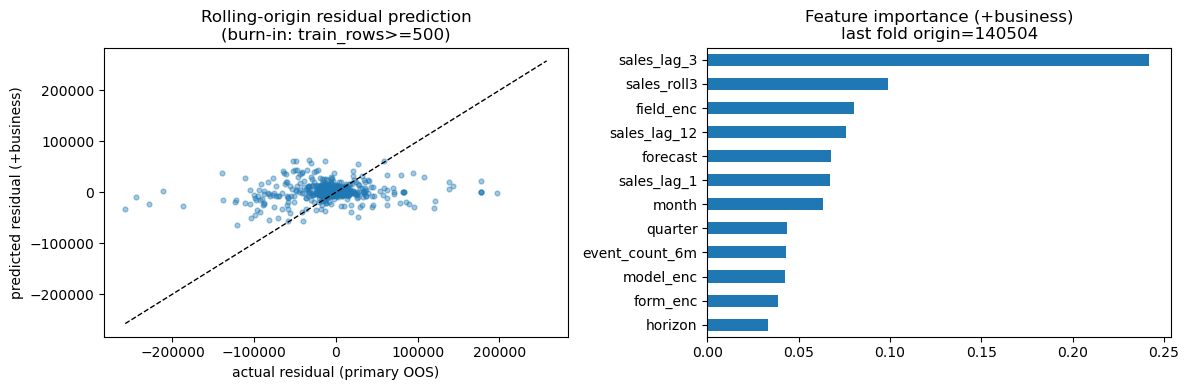

Best PRIMARY OOS RMSE: base_ts (20129.20) vs base_ts (20129.20)
RMSE reduction vs base: 0.0%
Primary metrics use origins [140310, 140401, 140404, 140407, 140410, 140504] (train_rows>=500); burn-in excluded=[140304, 140306, 140307]
Feature importance from last successful fold model (origin=140504)


,model,rmse,mae,mape,wmape,bias
0,base_ts,20129.199805,6429.907319,62.198776,37.142132,1568.856504
1,xgb_baseline,20236.359786,6566.463517,75.131634,37.930944,1573.013909
2,xgb_baseline_plus_business,20511.821261,6645.341280,57.897716,38.386579,1777.621679


In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(
    rolling_predictions_primary["residual"],
    rolling_predictions_primary["pred_resid_biz"],
    alpha=0.4,
    s=12,
)
lim = np.nanmax(
    np.abs(rolling_predictions_primary[["residual", "pred_resid_biz"]].to_numpy())
)
axes[0].plot([-lim, lim], [-lim, lim], "k--", lw=1)
axes[0].set_xlabel("actual residual (primary OOS)")
axes[0].set_ylabel("predicted residual (+business)")
axes[0].set_title(
    f"Rolling-origin residual prediction\n(burn-in: train_rows>={MIN_TRAIN_ROWS_FOR_PRIMARY})"
)

imp = pd.Series(model_biz.feature_importances_, index=ALL_FEATURES).sort_values()
imp.tail(12).plot(kind="barh", ax=axes[1])
axes[1].set_title(f"Feature importance (+business)\nlast fold origin={last_fold_origin}")
plt.tight_layout()
plt.show()

winner = overall_oos.sort_values("rmse").iloc[0]["model"]
base_rmse = overall_oos.loc[overall_oos["model"] == "base_ts", "rmse"].iloc[0]
best_rmse = overall_oos["rmse"].min()
print(
    f"Best PRIMARY OOS RMSE: {winner} ({best_rmse:.2f}) vs base_ts ({base_rmse:.2f})"
)
print(f"RMSE reduction vs base: {(base_rmse - best_rmse) / base_rmse * 100:.1f}%")
print(
    f"Primary metrics use origins {primary_origins} "
    f"(train_rows>={MIN_TRAIN_ROWS_FOR_PRIMARY}); burn-in excluded={burnin_origins}"
)
print(
    f"Feature importance from last successful fold model (origin={last_fold_origin})"
)
overall_oos


## Line Budget residual correction (rolling-origin, parallel)

Same algorithm as the TS track: per budget `origin` O, train on `date < O`, test on `origin == O`, refit XGB, burn-in at `train_rows >= 500`.

Primary metrics use `budget_rolling_predictions_primary`. Side-by-side comparison with TS follows.


In [15]:
from IPython.display import display

# Prep budget modeling frame
budget_feat_model = budget_feat.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["residual", "forecast", "sales"]
).copy()
for c in ["sales_lag_1", "sales_lag_2", "sales_lag_3", "sales_lag_12", "sales_roll3"]:
    budget_feat_model[c] = budget_feat_model[c].fillna(0)

print(
    "budget_feat_model",
    len(budget_feat_model),
    "products",
    budget_feat_model["product"].nunique(),
)

budget_pred_parts = []
budget_fold_rows = []
budget_model_base = None
budget_model_biz = None
budget_last_fold_origin = None

for O in sorted(budget_feat_model["origin"].astype(int).unique()):
    train = budget_feat_model.loc[budget_feat_model["date"].astype(int) < O].copy()
    test = budget_feat_model.loc[budget_feat_model["origin"].astype(int) == O].copy()
    if train.empty or test.empty:
        print(f"budget skip origin={O}: train={len(train)} test={len(test)}")
        continue

    train_date_max = int(train["date"].max())
    assert train_date_max < int(O), (
        f"budget leakage: train.date.max={train_date_max} not < test_origin={O}"
    )

    mb = fit_model(BASELINE_FEATURES, train)
    mz = fit_model(ALL_FEATURES, train)
    fold = test.copy()
    fold["pred_resid_base"] = mb.predict(test[BASELINE_FEATURES])
    fold["pred_resid_biz"] = mz.predict(test[ALL_FEATURES])
    fold["forecast_adj_base"] = np.maximum(0, fold["forecast"] + fold["pred_resid_base"])
    fold["forecast_adj_biz"] = np.maximum(0, fold["forecast"] + fold["pred_resid_biz"])
    fold["test_origin"] = int(O)
    fold["train_date_max"] = train_date_max
    fold["train_rows"] = len(train)
    budget_pred_parts.append(fold)

    budget_fold_rows.append(
        {
            "test_origin": int(O),
            "train_rows": len(train),
            "test_rows": len(test),
            "train_date_min": int(train["date"].min()),
            "train_date_max": train_date_max,
            "test_date_min": int(test["date"].min()),
            "test_date_max": int(test["date"].max()),
            "n_test_products": int(test["product"].nunique()),
            "test_qrts": sorted(test["qrt"].astype(str).unique().tolist()),
        }
    )
    budget_model_base, budget_model_biz = mb, mz
    budget_last_fold_origin = int(O)
    print(
        f"budget fold origin={O}: train={len(train)} "
        f"(dates {int(train['date'].min())}..{train_date_max}) "
        f"test={len(test)}"
    )

assert budget_pred_parts, "no budget rolling-origin folds"
budget_rolling_predictions = pd.concat(budget_pred_parts, ignore_index=True)
budget_fold_diagnostics = pd.DataFrame(budget_fold_rows)
budget_fold_diagnostics["in_primary"] = (
    budget_fold_diagnostics["train_rows"].astype(int) >= MIN_TRAIN_ROWS_FOR_PRIMARY
)
budget_primary_origins = sorted(
    budget_fold_diagnostics.loc[
        budget_fold_diagnostics["in_primary"], "test_origin"
    ]
    .astype(int)
    .tolist()
)
budget_burnin_origins = sorted(
    budget_fold_diagnostics.loc[
        ~budget_fold_diagnostics["in_primary"], "test_origin"
    ]
    .astype(int)
    .tolist()
)
budget_rolling_predictions_primary = budget_rolling_predictions[
    budget_rolling_predictions["test_origin"].astype(int).isin(budget_primary_origins)
].copy()

print(
    f"\nbudget burn-in (MIN_TRAIN_ROWS_FOR_PRIMARY={MIN_TRAIN_ROWS_FOR_PRIMARY})"
)
print(f"budget primary origins: {budget_primary_origins}")
print(f"budget burn-in origins: {budget_burnin_origins}")
print(
    f"budget_rolling_predictions_primary rows="
    f"{len(budget_rolling_predictions_primary)} / {len(budget_rolling_predictions)}"
)
assert len(budget_primary_origins) > 0, "no budget folds passed burn-in"
display(budget_fold_diagnostics)

print("\n=== BUDGET PRIMARY overall OOS ===")
budget_overall_oos = overall_metrics_table(budget_rolling_predictions_primary)
display(budget_overall_oos)

print("\n=== BUDGET PRIMARY by-horizon RMSE ===")
b_rows = []
for h, g in budget_rolling_predictions_primary.groupby("horizon"):
    b_rows.append(metrics_block(g["sales"], g["forecast"], f"base_h{h}"))
    b_rows.append(metrics_block(g["sales"], g["forecast_adj_base"], f"xgb_base_h{h}"))
    b_rows.append(metrics_block(g["sales"], g["forecast_adj_biz"], f"xgb_biz_h{h}"))
budget_by_horizon_oos = pd.DataFrame(b_rows)
budget_by_horizon_oos["horizon"] = (
    budget_by_horizon_oos["model"].str.extract(r"h(\d+)").astype(int)
)
budget_by_horizon_oos["kind"] = budget_by_horizon_oos["model"].str.replace(
    r"_h\d+", "", regex=True
)
display(budget_by_horizon_oos.pivot(index="horizon", columns="kind", values="rmse"))

print("\n=== SIDE-BY-SIDE: TS vs Line Budget (primary OOS) ===")
ts_cmp = overall_oos.copy()
ts_cmp.insert(0, "source", "ts")
bud_cmp = budget_overall_oos.copy()
bud_cmp.insert(0, "source", "line_budget")
side_by_side = pd.concat([ts_cmp, bud_cmp], ignore_index=True)
display(side_by_side)

for label, table in [("TS", overall_oos), ("Line Budget", budget_overall_oos)]:
    w = table.sort_values("rmse").iloc[0]
    base = table.loc[table["model"] == "base_ts", "rmse"].iloc[0]
    print(
        f"{label}: best={w['model']} RMSE={w['rmse']:.2f} "
        f"vs base_ts={base:.2f} "
        f"({(base - w['rmse']) / base * 100:.1f}% reduction)"
    )


budget_feat_model 4453 products 55
budget skip origin=140304: train=0 test=825
budget fold origin=140307: train=165 (dates 140304..140306) test=780
budget fold origin=140310: train=486 (dates 140304..140309) test=777
budget fold origin=140312: train=804 (dates 140304..140311) test=148
budget fold origin=140404: train=1480 (dates 140304..140403) test=715
budget fold origin=140407: train=2152 (dates 140304..140406) test=550
budget fold origin=140410: train=2824 (dates 140304..140409) test=385
budget fold origin=140501: train=3502 (dates 140304..140412) test=220
budget fold origin=140504: train=4180 (dates 140304..140503) test=53

budget burn-in (MIN_TRAIN_ROWS_FOR_PRIMARY=500)
budget primary origins: [140312, 140404, 140407, 140410, 140501, 140504]
budget burn-in origins: [140307, 140310]
budget_rolling_predictions_primary rows=2071 / 3628


,test_origin,train_rows,test_rows,train_date_min,train_date_max,test_date_min,test_date_max,n_test_products,test_qrts,in_primary
0,140307,165,780,140304,140306,140307,140409,52,[1403Q3],False
1,140310,486,777,140304,140309,140310,140412,52,[1403Q4],False
2,140312,804,148,140304,140311,140312,140502,10,"[1403Q4, 1404Q1]",True
3,140404,1480,715,140304,140403,140404,140504,55,[1404Q2],True
4,140407,2152,550,140304,140406,140407,140504,55,[1404Q3],True
5,140410,2824,385,140304,140409,140410,140504,55,[1404Q4],True
6,140501,3502,220,140304,140412,140501,140504,55,[1405Q1],True
7,140504,4180,53,140304,140503,140504,140504,53,[1405Q2],True



=== BUDGET PRIMARY overall OOS ===


,model,rmse,mae,mape,wmape,bias
0,base_ts,20410.731347,6542.454091,99.859350,38.172152,1565.853863
1,xgb_baseline,19145.719039,6186.283993,95.648033,36.094066,869.010844
2,xgb_baseline_plus_business,19653.248864,6357.188389,99.954638,37.091213,1063.222021



=== BUDGET PRIMARY by-horizon RMSE ===


kind,base,xgb_base,xgb_biz
horizon,,,
1,19257.155419,17971.028602,19011.315756
2,15044.471315,14936.609323,14356.935898
3,14279.775408,14529.744789,14231.845616
4,21752.238072,19790.804648,19414.312006
5,17705.400571,16663.147207,17783.984158
6,18365.365421,15478.852165,16925.509845
7,22777.137746,21164.916426,21428.738242
8,19954.839971,18176.102860,19243.509873
9,21471.934645,18908.061303,19843.680449



=== SIDE-BY-SIDE: TS vs Line Budget (primary OOS) ===


,source,model,rmse,mae,mape,wmape,bias
0,ts,base_ts,20129.199805,6429.907319,62.198776,37.142132,1568.856504
1,ts,xgb_baseline,20236.359786,6566.463517,75.131634,37.930944,1573.013909
2,ts,xgb_baseline_plus_business,20511.821261,6645.341280,57.897716,38.386579,1777.621679
3,line_budget,base_ts,20410.731347,6542.454091,99.859350,38.172152,1565.853863
4,line_budget,xgb_baseline,19145.719039,6186.283993,95.648033,36.094066,869.010844
5,line_budget,xgb_baseline_plus_business,19653.248864,6357.188389,99.954638,37.091213,1063.222021


TS: best=base_ts RMSE=20129.20 vs base_ts=20129.20 (0.0% reduction)
Line Budget: best=xgb_baseline RMSE=19145.72 vs base_ts=20410.73 (6.2% reduction)


## Human–Machine Forecast Evaluation (primary)

Fair comparison of **TS** vs **Line Budget** vs clean residual XGBoost models on **identical** `(product, qrt, target_date)` rows.

### Provenance (do not confuse these)

| Field | Meaning in this notebook |
|-------|--------------------------|
| `qrt` | Planning-cycle label (`1404Q4`). TS: CSV name. Budget: from Iris `Version` YYYYQQEE. |
| `budget_version` | Iris edition code; earliest edition per product-qrt. |
| `target_date` | Shamsi YYYYMM month being forecast (actual sales month). |
| `ts_origin` | First month of the TS 15-month window in that CSV. |
| `budget_origin` | **Inferred** as `min(target_date)` in that product-qrt budget vintage — **not** a known human creation/planning timestamp. |

**Limitation:** true Budget creation date cannot be derived from available fields.

### Alignment rule

- `matched_all`: TS ∩ Budget ∩ actuals on `(product, qrt, date)`
- `matched_aligned`: `matched_all` where **`same_horizon`** (`ts_horizon == budget_horizon`)

`same_origin` is reported but **not** required for the ML universe (origins often differ because Budget origin is inferred).

### Models (clean quantitative features only — no event/activity)

| Name | Role |
|------|------|
| `ts` | raw TS forecast |
| `human_budget` | raw Line Budget |
| `ts_residual_xgb` | XGB corrects TS residual |
| `budget_residual_xgb` | XGB corrects Budget residual |
| `integrated_budget_residual_xgb` | XGB corrects Budget residual using TS + human_adjustment |

Rolling-origin fold key = `ts_origin`; burn-in = `train_rows >= MIN_TRAIN_ROWS_FOR_PRIMARY`.


=== data-quality surface (not auto-fixed) ===
ALLOWED_FORECAST_QRTS (9): ['1403Q1', '1403Q2', '1403Q3', '1403Q4', '1404Q1', '1404Q2', '1404Q3', '1404Q4', '1405Q2']
ALLOWED_FORECAST_QRTS tokens look well-formed.

=== STEP 1: vintage alignment audit ===
Alignment rule for matched_aligned: same_horizon (ts_horizon == budget_horizon). same_origin is NOT required because budget_origin is inferred as min(target date) in the product-qrt vintage — not a known Sales creation timestamp.
1. matched_all observations: 3983
   matched_aligned (same_horizon): 3184 (79.9%)
2. % same origin: 79.9%
3. % same horizon: 79.9%
4. horizon-difference distribution:


,n
horizon_difference,
-2,689
-1,84
0,3184
2,26


5. origin-difference_months distribution:


,n
origin_difference_months,
-2,26
0,3184
1,84
2,689


6–7, 9–10. agreement / products / origins / versions by qrt:


...

,horizon_bucket,n,TS_WMAPE,Budget_WMAPE,Budget_relative_improvement,Budget_win_rate,mean_human_FVA,median_human_FVA,mean_human_adjustment
0,1-3,842,32.367801,32.610703,-0.750444,0.427553,-41.807967,0.0,480.017490
1,13-15,356,36.917127,41.777547,-13.165759,0.421348,-842.919944,0.0,-2108.377809
2,4-6,789,35.731894,38.565227,-7.929424,0.452471,-477.044505,0.0,-992.087929
3,7-12,1197,37.125956,45.044244,-21.328171,0.437761,-1371.598997,0.0,-1410.362573


by product (head):


,product,n,TS_WMAPE,Budget_WMAPE,Budget_relative_improvement,Budget_win_rate,mean_human_FVA,median_human_FVA,mean_human_adjustment
0,Altebrel 25,61,19.568850,22.575958,-15.366807,0.213115,-293.803279,0.0,1027.540984
40,Paglino 25,61,43.390365,177.024766,-307.981739,0.131148,-6403.344262,-5332.0,7625.704918
1,Altebrel 50,61,17.042791,17.963631,-5.403107,0.180328,-357.295082,0.0,-728.245902
29,Cinnopar,61,22.313351,17.237055,22.750039,0.540984,1336.408155,262.0,-343.686843
30,Cinnora AutoInjector,61,40.011822,35.377944,11.581273,0.459016,4679.147541,0.0,-4002.786885
31,Clastoz,61,19.285561,19.723968,-2.273240,0.295082,-12.355247,0.0,-40.957405
32,Dactoma,61,65.155836,72.726964,-11.620030,0.426230,-36.557377,-30.0,27.344262
33,Dalfyra,61,18.551894,22.380809,-20.638945,0.409836,-649.950820,-152.0,-2278.508197
34,FolicoGen,61,28.366467,31.524220,-11.131992,0.491803,-2541.327869,-229.0,6316.868852
37,Lyratan,61,17.539153,20.224377,-15.309888,0.245902,-79.573770,0.0,-72.229508


by adjustment direction:


,adj_direction,n,TS_WMAPE,Budget_WMAPE,Budget_relative_improvement,Budget_win_rate,mean_human_FVA,median_human_FVA,mean_human_adjustment
0,DOWN,1439,36.877646,39.789284,-7.895401,0.536484,-481.268842,12.0,-5876.893254
1,UNCHANGED,408,39.055758,39.055758,0.000000,0.000000,0.000000,0.0,0.000000
2,UP,1337,32.585263,40.127609,-23.146494,0.462977,-1242.279775,-16.0,4218.010653


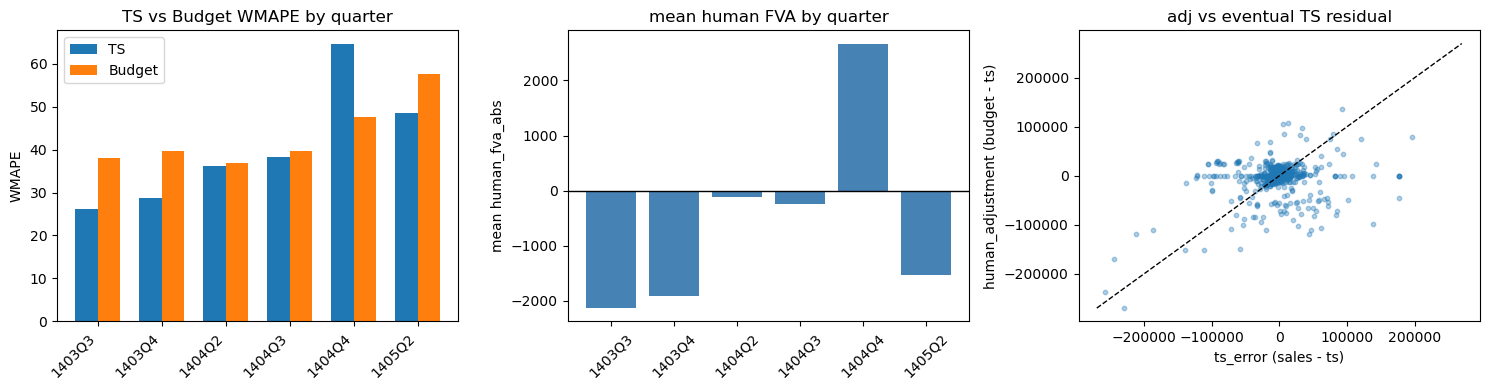


=== STEP 5: clean features (no business) ===
TS_RESID_FEATURES 13 ['ts_forecast', 'horizon', 'month', 'quarter', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_12', 'sales_roll3', 'model_enc', 'field_enc', 'form_enc', 'provider_enc']
BUDGET_RESID_FEATURES 13 ['budget_forecast', 'horizon', 'month', 'quarter', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_12', 'sales_roll3', 'model_enc', 'field_enc', 'form_enc', 'provider_enc']
INTEGRATED_FEATURES 15 ['budget_forecast', 'ts_forecast', 'human_adjustment', 'horizon', 'month', 'quarter', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_12', 'sales_roll3', 'model_enc', 'field_enc', 'form_enc', 'provider_enc']

=== STEPS 6–8: HM models on matched_aligned ===
hm rows=3184 products=55 origins=[140307, 140310, 140404, 140407, 140410, 140504]
hm skip origin=140307: train=0 test=765
hm fold origin=140310: train=153 (140307..140309) test=762
hm fold origin=140404: train=765 (140307..140403) test=689
hm fold origin=140407:

,origin,train_rows,train_date_min,train_date_max,historical_months,prior_forecast_vintages,test_rows,test_horizons,n_test_products,test_qrts,in_primary
0,140310,153,140307,140309,3,1,762,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",51,[1403Q4],False
1,140404,765,140307,140403,9,2,689,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]",53,[1404Q2],True
2,140407,1230,140307,140406,12,3,530,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",53,[1404Q3],True
3,140410,1854,140307,140409,15,4,385,"[1, 2, 3, 4, 5, 6, 7]",55,[1404Q4],True
4,140504,2970,140307,140503,21,5,53,[1],53,[1405Q2],True



=== STEP 9: five-model primary OOS (matched_aligned, identical rows) ===


,model,rmse,mae,mape,wmape,bias,n,vs_TS_pct,vs_Human_pct
0,ts,24211.068752,7279.744116,54.908122,43.384159,1760.456246,1657,0.000000,-6.453067
1,human_budget,21263.373412,6838.454087,56.434504,40.754260,1921.397315,1657,6.061889,0.000000
2,ts_residual_xgb,24142.114524,7172.461669,65.795021,42.744802,1766.791047,1657,1.473712,-4.884256
3,budget_residual_xgb,19396.822575,6232.327092,96.876734,37.142002,1226.429127,1657,14.388102,8.863509
4,integrated_budget_residual_xgb,20582.069372,6602.138611,58.563189,39.345921,1896.059680,1657,9.308095,3.455686



=== STEP 10: model metrics by origin (primary) ===


,origin,train_rows,historical_months,prior_forecast_vintages,test_rows,available_horizons,model,rmse,mae,mape,wmape,bias
0,140404,765,9,2,689,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]",ts,19689.440408,6217.447025,45.027736,36.152679,-394.611030
1,140404,765,9,2,689,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]",human_budget,20009.882685,6338.013062,48.091368,36.853736,1313.647315
2,140404,765,9,2,689,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]",ts_residual_xgb,19965.377809,6209.712867,54.225351,36.107707,-536.087831
3,140404,765,9,2,689,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]",budget_residual_xgb,19997.841597,6223.535461,80.954999,36.188082,1702.201200
4,140404,765,9,2,689,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]",integrated_budget_residual_xgb,19835.723865,6237.313375,54.808293,36.268197,780.959478
5,140407,1230,12,3,530,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",ts,19785.385910,6537.886792,50.935273,38.277404,1372.411321
6,140407,1230,12,3,530,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",human_budget,20998.381904,6786.073156,52.062822,39.730462,2182.114530
7,140407,1230,12,3,530,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",ts_residual_xgb,18681.020491,6407.122139,65.342043,37.511816,2065.181938
8,140407,1230,12,3,530,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",budget_residual_xgb,18957.879048,6175.820260,51.727144,36.157611,673.654471
9,140407,1230,12,3,530,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",integrated_budget_residual_xgb,19292.918097,6368.778796,53.117360,37.287327,2161.431684



=== STEP 11a: WMAPE by horizon bucket ===


model,budget_residual_xgb,human_budget,integrated_budget_residual_xgb,ts,ts_residual_xgb
horizon_bucket,,,,,
1-3,30.955453,33.083476,33.159560,36.286250,37.684995
13-15,61.564043,63.746738,69.515525,65.211165,64.090402
4-6,33.102212,36.444992,33.554380,41.004360,41.255981
7-12,44.086534,49.437515,47.243029,50.015691,46.772179



=== STEP 11b: product-level robustness ===


,model,n_products,pct_products_beat_ts,pct_products_beat_human,median_imp_vs_ts,p25_imp_vs_ts,p75_imp_vs_ts,median_imp_vs_human,p25_imp_vs_human,p75_imp_vs_human
0,ts,55,0.000000,0.436364,0.000000,0.000000,0.000000,-1.174628,-5.825953,2.698403
1,human_budget,55,0.527273,0.000000,1.174628,-2.698403,5.825953,0.000000,0.000000,0.000000
2,ts_residual_xgb,55,0.545455,0.363636,0.604434,-3.388222,2.355235,-1.900989,-7.880869,3.688610
3,budget_residual_xgb,55,0.527273,0.545455,1.072603,-4.351122,5.510393,0.445332,-2.292794,1.980753
4,integrated_budget_residual_xgb,55,0.600000,0.563636,1.829191,-1.792171,4.759944,0.723400,-1.382607,2.518969


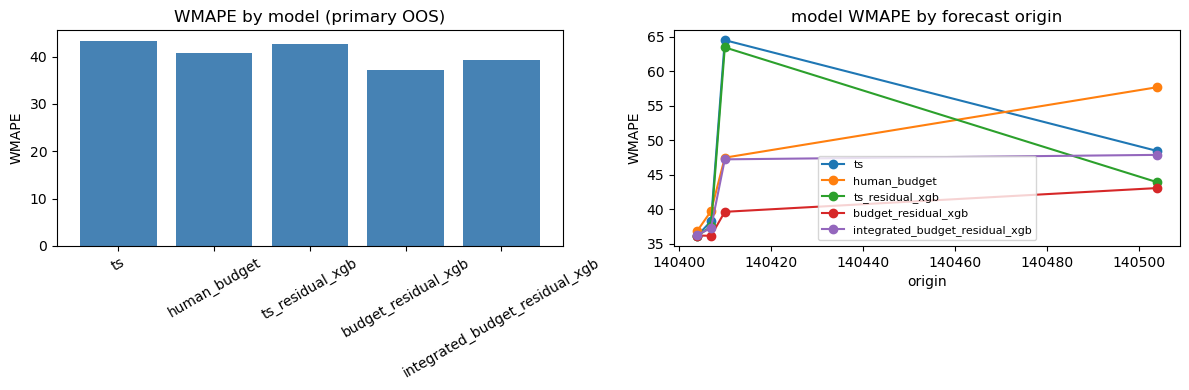


Primary HM analysis complete.


In [16]:
from IPython.display import display
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Constants (documented; not tuned on final eval origins)
# ---------------------------------------------------------------------------
ADJ_TOLERANCE = 0.0  # |adj| <= tol => UNCHANGED
REL_ADJ_EPS = 1.0  # relative adj only if |ts_forecast| >= eps
FVA_TIE_TOL = 0.0  # |human_fva_abs| <= tol => tie

HORIZON_BUCKETS = [
    ("1-3", 1, 3),
    ("4-6", 4, 6),
    ("7-12", 7, 12),
    ("13-15", 13, 15),
]


def horizon_bucket(h: int) -> str:
    h = int(h)
    for name, lo, hi in HORIZON_BUCKETS:
        if lo <= h <= hi:
            return name
    return "other"


def wmape_series(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom == 0:
        return float("nan")
    return float(np.abs(y_true - y_pred).sum() / denom * 100.0)


# Surface allowlist anomalies (do not silently fix)
_qrt_tokens = list(ALLOWED_FORECAST_QRTS)
_odd_qrts = [q for q in _qrt_tokens if not (
    isinstance(q, str) and len(q) >= 6 and "Q" in q and q.count("Q") == 1
)]
print("=== data-quality surface (not auto-fixed) ===")
print(f"ALLOWED_FORECAST_QRTS ({len(_qrt_tokens)}): {_qrt_tokens}")
if _odd_qrts:
    print("WARNING: odd ALLOWED_FORECAST_QRTS tokens (possible missing commas):", _odd_qrts)
else:
    print("ALLOWED_FORECAST_QRTS tokens look well-formed.")

# ---------------------------------------------------------------------------
# STEP 1 — Build matched_all / matched_aligned + vintage alignment audit
# ---------------------------------------------------------------------------
ts_side = feat_model.copy()
ts_side = ts_side.rename(
    columns={
        "forecast": "ts_forecast",
        "origin": "ts_origin",
        "horizon": "ts_horizon",
        "residual": "ts_residual",
    }
)

budget_side = budget_panel[
    ["product", "qrt", "date", "forecast", "origin", "horizon", "version", "sales"]
].copy()
budget_side = budget_side.rename(
    columns={
        "forecast": "budget_forecast",
        "origin": "budget_origin",
        "horizon": "budget_horizon",
        "version": "budget_version",
        "sales": "budget_sales",
    }
)

matched_all = ts_side.merge(
    budget_side, on=["product", "qrt", "date"], how="inner", suffixes=("", "_bud")
)
matched_all["sales"] = matched_all["sales"].astype(float)
matched_all["target_date"] = matched_all["date"].astype(int)
matched_all["ts_origin"] = matched_all["ts_origin"].astype(int)
matched_all["budget_origin"] = matched_all["budget_origin"].astype(int)
matched_all["ts_horizon"] = matched_all["ts_horizon"].astype(int)
matched_all["budget_horizon"] = matched_all["budget_horizon"].astype(int)
matched_all["budget_version"] = matched_all["budget_version"].astype(int)

# origin_difference_months: months from budget_origin to ts_origin (ts - budget)
matched_all["origin_difference_months"] = [
    shamsi_month_diff(int(t), int(b))
    for t, b in zip(matched_all["ts_origin"], matched_all["budget_origin"])
]
matched_all["horizon_difference"] = (
    matched_all["ts_horizon"] - matched_all["budget_horizon"]
)
matched_all["same_origin"] = matched_all["ts_origin"] == matched_all["budget_origin"]
matched_all["same_horizon"] = matched_all["ts_horizon"] == matched_all["budget_horizon"]

# Human adjustment / errors (shared)
matched_all["human_adjustment"] = (
    matched_all["budget_forecast"] - matched_all["ts_forecast"]
)
matched_all["ts_error"] = matched_all["sales"] - matched_all["ts_forecast"]
matched_all["budget_error"] = matched_all["sales"] - matched_all["budget_forecast"]
matched_all["human_fva_abs"] = (
    matched_all["ts_error"].abs() - matched_all["budget_error"].abs()
)
_ts_abs = matched_all["ts_forecast"].abs()
matched_all["relative_human_adjustment"] = np.where(
    _ts_abs >= REL_ADJ_EPS,
    matched_all["human_adjustment"] / matched_all["ts_forecast"],
    np.nan,
)
matched_all["adj_direction"] = np.where(
    matched_all["human_adjustment"] > ADJ_TOLERANCE,
    "UP",
    np.where(matched_all["human_adjustment"] < -ADJ_TOLERANCE, "DOWN", "UNCHANGED"),
)
matched_all["horizon"] = matched_all["ts_horizon"]  # fold/display default = TS horizon
matched_all["horizon_bucket"] = matched_all["horizon"].map(horizon_bucket)
matched_all["origin"] = matched_all["ts_origin"]  # rolling-origin fold key

# Alignment rule (documented): same months-ahead only
matched_aligned = matched_all.loc[matched_all["same_horizon"]].copy()

print("\n=== STEP 1: vintage alignment audit ===")
print(
    "Alignment rule for matched_aligned: same_horizon "
    "(ts_horizon == budget_horizon). same_origin is NOT required "
    "because budget_origin is inferred as min(target date) in the "
    "product-qrt vintage — not a known Sales creation timestamp."
)
n_all = len(matched_all)
n_aligned = len(matched_aligned)
print(f"1. matched_all observations: {n_all}")
print(f"   matched_aligned (same_horizon): {n_aligned} ({n_aligned / max(n_all, 1):.1%})")
print(f"2. % same origin: {matched_all['same_origin'].mean():.1%}")
print(f"3. % same horizon: {matched_all['same_horizon'].mean():.1%}")
print("4. horizon-difference distribution:")
display(matched_all["horizon_difference"].value_counts().sort_index().to_frame("n"))
print("5. origin-difference_months distribution:")
display(
    matched_all["origin_difference_months"].value_counts().sort_index().to_frame("n")
)

agree_by_qrt = (
    matched_all.groupby("qrt")
    .agg(
        n=("product", "size"),
        n_products=("product", "nunique"),
        pct_same_origin=("same_origin", "mean"),
        pct_same_horizon=("same_horizon", "mean"),
        ts_origins=("ts_origin", lambda s: sorted({int(x) for x in s})),
        budget_origins=("budget_origin", lambda s: sorted({int(x) for x in s})),
        budget_versions=("budget_version", lambda s: sorted({int(x) for x in s})),
    )
    .reset_index()
)
print("6–7, 9–10. agreement / products / origins / versions by qrt:")
display(agree_by_qrt)

mismatch = matched_all.loc[~matched_all["same_horizon"]].copy()
print(f"8. mismatched horizon examples (n={len(mismatch)}):")
display(
    mismatch[
        [
            "product",
            "qrt",
            "target_date",
            "ts_origin",
            "ts_horizon",
            "ts_forecast",
            "budget_version",
            "budget_origin",
            "budget_horizon",
            "budget_forecast",
            "sales",
            "origin_difference_months",
            "horizon_difference",
        ]
    ]
    .head(15)
)

audit_cols = [
    "product",
    "qrt",
    "target_date",
    "ts_origin",
    "ts_horizon",
    "ts_forecast",
    "budget_version",
    "budget_origin",
    "budget_horizon",
    "budget_forecast",
    "sales",
    "origin_difference_months",
    "horizon_difference",
    "same_origin",
    "same_horizon",
]
print("audit head (matched_all):")
display(matched_all[audit_cols].head())

# Alias for explorer / backward compat
matched = matched_all

# ---------------------------------------------------------------------------
# STEP 2 — Fair TS vs Human Budget on identical rows
# ---------------------------------------------------------------------------


def fair_ts_vs_budget(df: pd.DataFrame, label: str) -> pd.DataFrame:
    y = df["sales"]
    out = pd.DataFrame(
        [
            metrics_block(y, df["ts_forecast"], "ts"),
            metrics_block(y, df["budget_forecast"], "human_budget"),
        ]
    )
    out.insert(0, "universe", label)
    out.insert(2, "n", len(df))
    fva = df["human_fva_abs"]
    budget_wins = (fva > FVA_TIE_TOL).mean()
    ts_wins = (fva < -FVA_TIE_TOL).mean()
    ties = (fva.abs() <= FVA_TIE_TOL).mean()
    print(f"\n=== STEP 2: fair TS vs Budget ({label}, n={len(df)}) ===")
    display(out)
    print(
        f"Budget beats TS: {budget_wins:.1%} | TS beats Budget: {ts_wins:.1%} | "
        f"tie (|fva|<={FVA_TIE_TOL}): {ties:.1%}"
    )
    print(
        f"mean human_fva_abs={fva.mean():.2f}  median={fva.median():.2f}  "
        f"(positive => Budget closer)"
    )
    return out


fair_all = fair_ts_vs_budget(matched_all, "matched_all")
fair_aligned = fair_ts_vs_budget(matched_aligned, "matched_aligned")
fair_comparison = pd.concat([fair_all, fair_aligned], ignore_index=True)

# ---------------------------------------------------------------------------
# STEP 3 — Human adjustment analysis
# ---------------------------------------------------------------------------
print("\n=== STEP 3: human adjustment (matched_aligned primary) ===")
print(
    f"ADJ_TOLERANCE={ADJ_TOLERANCE}  REL_ADJ_EPS={REL_ADJ_EPS}  "
    f"FVA_TIE_TOL={FVA_TIE_TOL}"
)
print("human_adjustment distribution:")
display(matched_aligned["human_adjustment"].describe())
print("relative_human_adjustment (stable rows only):")
display(matched_aligned["relative_human_adjustment"].describe())

corr_adj = matched_aligned["human_adjustment"].corr(matched_aligned["ts_error"])
print(
    f"corr(human_adjustment, sales-ts_forecast) = {corr_adj:.4f}  "
    "(predictive ASSOCIATION, not causality)"
)


def direction_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for direction, g in df.groupby("adj_direction"):
        rows.append(
            {
                "direction": direction,
                "n": len(g),
                "mean_human_adjustment": g["human_adjustment"].mean(),
                "median_human_adjustment": g["human_adjustment"].median(),
                "ts_wmape": wmape_series(g["sales"], g["ts_forecast"]),
                "budget_wmape": wmape_series(g["sales"], g["budget_forecast"]),
                "mean_human_fva": g["human_fva_abs"].mean(),
                "pct_adj_improved_abs_error": (g["human_fva_abs"] > FVA_TIE_TOL).mean(),
            }
        )
    return pd.DataFrame(rows).sort_values("direction")


adj_dir_aligned = direction_summary(matched_aligned)
print("adjustment direction summary (matched_aligned):")
display(adj_dir_aligned)

adj_dir_all = direction_summary(matched_all)
print("adjustment direction summary (matched_all, sensitivity):")
display(adj_dir_all)

# ---------------------------------------------------------------------------
# STEP 4 — Human FVA by segment
# ---------------------------------------------------------------------------


def fva_segment_table(df: pd.DataFrame, group_cols) -> pd.DataFrame:
    rows = []
    for key, g in df.groupby(group_cols):
        if not isinstance(key, tuple):
            key = (key,)
        rec = dict(zip(group_cols if isinstance(group_cols, list) else [group_cols], key))
        ts_w = wmape_series(g["sales"], g["ts_forecast"])
        bud_w = wmape_series(g["sales"], g["budget_forecast"])
        rec.update(
            {
                "n": len(g),
                "TS_WMAPE": ts_w,
                "Budget_WMAPE": bud_w,
                "Budget_relative_improvement": (ts_w - bud_w) / ts_w * 100.0
                if ts_w and np.isfinite(ts_w) and ts_w != 0
                else np.nan,
                "Budget_win_rate": (g["human_fva_abs"] > FVA_TIE_TOL).mean(),
                "mean_human_FVA": g["human_fva_abs"].mean(),
                "median_human_FVA": g["human_fva_abs"].median(),
                "mean_human_adjustment": g["human_adjustment"].mean(),
            }
        )
        rows.append(rec)
    return pd.DataFrame(rows)


print("\n=== STEP 4: Human FVA by segment (matched_aligned) ===")
fva_by_qrt = fva_segment_table(matched_aligned, ["qrt"])
print("main quarter-level table:")
display(
    fva_by_qrt[
        [
            "qrt",
            "n",
            "TS_WMAPE",
            "Budget_WMAPE",
            "Budget_relative_improvement",
            "Budget_win_rate",
            "mean_human_FVA",
        ]
    ].sort_values("qrt")
)

fva_by_horizon = fva_segment_table(matched_aligned, ["horizon"])
print("by forecast horizon:")
display(fva_by_horizon.sort_values("horizon"))

fva_by_bucket = fva_segment_table(matched_aligned, ["horizon_bucket"])
print("by horizon bucket:")
display(fva_by_bucket)

fva_by_product = fva_segment_table(matched_aligned, ["product"])
print("by product (head):")
display(fva_by_product.sort_values("n", ascending=False).head(15))

fva_by_direction = fva_segment_table(matched_aligned, ["adj_direction"])
print("by adjustment direction:")
display(fva_by_direction)

# Primary plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
q = fva_by_qrt.sort_values("qrt")
x = np.arange(len(q))
w = 0.35
axes[0].bar(x - w / 2, q["TS_WMAPE"], w, label="TS")
axes[0].bar(x + w / 2, q["Budget_WMAPE"], w, label="Budget")
axes[0].set_xticks(x)
axes[0].set_xticklabels(q["qrt"], rotation=45, ha="right")
axes[0].set_ylabel("WMAPE")
axes[0].set_title("TS vs Budget WMAPE by quarter")
axes[0].legend()

axes[1].bar(q["qrt"].astype(str), q["mean_human_FVA"], color="steelblue")
axes[1].axhline(0, color="k", lw=1)
axes[1].set_title("mean human FVA by quarter")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylabel("mean human_fva_abs")

axes[2].scatter(
    matched_aligned["ts_error"],
    matched_aligned["human_adjustment"],
    alpha=0.35,
    s=10,
)
lim = float(
    np.nanmax(np.abs(matched_aligned[["ts_error", "human_adjustment"]].to_numpy()))
)
axes[2].plot([-lim, lim], [-lim, lim], "k--", lw=1)
axes[2].set_xlabel("ts_error (sales - ts)")
axes[2].set_ylabel("human_adjustment (budget - ts)")
axes[2].set_title("adj vs eventual TS residual")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# STEP 5 — Clean feature sets (no business/event/activity)
# ---------------------------------------------------------------------------
CLEAN_QUANT_FEATURES = [
    "horizon",
    "month",
    "quarter",
    "sales_lag_1",
    "sales_lag_2",
    "sales_lag_3",
    "sales_lag_12",
    "sales_roll3",
    "model_enc",
    "field_enc",
    "form_enc",
    "provider_enc",
]
TS_RESID_FEATURES = ["ts_forecast"] + CLEAN_QUANT_FEATURES
BUDGET_RESID_FEATURES = ["budget_forecast"] + CLEAN_QUANT_FEATURES
INTEGRATED_FEATURES = [
    "budget_forecast",
    "ts_forecast",
    "human_adjustment",
] + CLEAN_QUANT_FEATURES

print("\n=== STEP 5: clean features (no business) ===")
print("TS_RESID_FEATURES", len(TS_RESID_FEATURES), TS_RESID_FEATURES)
print("BUDGET_RESID_FEATURES", len(BUDGET_RESID_FEATURES), BUDGET_RESID_FEATURES)
print("INTEGRATED_FEATURES", len(INTEGRATED_FEATURES), INTEGRATED_FEATURES)

# ---------------------------------------------------------------------------
# STEPS 6–8 — Rolling-origin models on matched_aligned identical rows
# ---------------------------------------------------------------------------
hm = matched_aligned.replace([np.inf, -np.inf], np.nan).dropna(
    subset=[
        "sales",
        "ts_forecast",
        "budget_forecast",
        "ts_residual",
        "human_adjustment",
        "horizon",
        "month",
        "quarter",
    ]
).copy()
for c in ["sales_lag_1", "sales_lag_2", "sales_lag_3", "sales_lag_12", "sales_roll3"]:
    hm[c] = hm[c].fillna(0)
for c in ["model_enc", "field_enc", "form_enc", "provider_enc"]:
    if c in hm.columns:
        hm[c] = hm[c].fillna(-1)

hm["ts_resid_target"] = hm["sales"] - hm["ts_forecast"]
hm["budget_resid_target"] = hm["sales"] - hm["budget_forecast"]

print(
    f"\n=== STEPS 6–8: HM models on matched_aligned ===\n"
    f"hm rows={len(hm)} products={hm['product'].nunique()} "
    f"origins={sorted(hm['origin'].astype(int).unique().tolist())}"
)

hm_pred_parts = []
hm_fold_rows = []
hm_model_ts = hm_model_budget = hm_model_integrated = None
hm_last_fold_origin = None

for O in sorted(hm["origin"].astype(int).unique()):
    train = hm.loc[hm["date"].astype(int) < O].copy()
    test = hm.loc[hm["origin"].astype(int) == O].copy()
    if train.empty or test.empty:
        print(f"hm skip origin={O}: train={len(train)} test={len(test)}")
        continue

    train_date_max = int(train["date"].max())
    assert train_date_max < int(O), (
        f"HM leakage: train.date.max={train_date_max} not < test_origin={O}"
    )

    # Model A: TS residual
    train_a = train.copy()
    train_a["residual"] = train_a["ts_resid_target"]
    m_ts = fit_model(TS_RESID_FEATURES, train_a)

    # Model B: Budget residual
    train_b = train.copy()
    train_b["residual"] = train_b["budget_resid_target"]
    m_bud = fit_model(BUDGET_RESID_FEATURES, train_b)

    # Model C: Integrated (budget residual + TS info)
    train_c = train.copy()
    train_c["residual"] = train_c["budget_resid_target"]
    m_int = fit_model(INTEGRATED_FEATURES, train_c)

    fold = test.copy()
    fold["pred_ts_resid"] = m_ts.predict(test[TS_RESID_FEATURES])
    fold["pred_budget_resid"] = m_bud.predict(test[BUDGET_RESID_FEATURES])
    fold["pred_integrated_resid"] = m_int.predict(test[INTEGRATED_FEATURES])
    fold["pred_ts"] = fold["ts_forecast"]
    fold["pred_human_budget"] = fold["budget_forecast"]
    fold["pred_ts_residual_xgb"] = np.maximum(
        0, fold["ts_forecast"] + fold["pred_ts_resid"]
    )
    fold["pred_budget_residual_xgb"] = np.maximum(
        0, fold["budget_forecast"] + fold["pred_budget_resid"]
    )
    fold["pred_integrated_budget_residual_xgb"] = np.maximum(
        0, fold["budget_forecast"] + fold["pred_integrated_resid"]
    )
    fold["test_origin"] = int(O)
    fold["train_date_max"] = train_date_max
    fold["train_date_min"] = int(train["date"].min())
    fold["train_rows"] = len(train)
    fold["prior_vintages"] = int(train["origin"].nunique())
    hm_pred_parts.append(fold)

    hm_fold_rows.append(
        {
            "origin": int(O),
            "train_rows": len(train),
            "train_date_min": int(train["date"].min()),
            "train_date_max": train_date_max,
            "historical_months": int(train["date"].nunique()),
            "prior_forecast_vintages": int(train["origin"].nunique()),
            "test_rows": len(test),
            "test_horizons": sorted({int(h) for h in test["horizon"]}),
            "n_test_products": int(test["product"].nunique()),
            "test_qrts": sorted(test["qrt"].astype(str).unique().tolist()),
        }
    )
    hm_model_ts, hm_model_budget, hm_model_integrated = m_ts, m_bud, m_int
    hm_last_fold_origin = int(O)
    print(
        f"hm fold origin={O}: train={len(train)} "
        f"({int(train['date'].min())}..{train_date_max}) test={len(test)}"
    )

assert hm_pred_parts, "no HM rolling-origin folds on matched_aligned"
hm_rolling_predictions = pd.concat(hm_pred_parts, ignore_index=True)
hm_fold_diagnostics = pd.DataFrame(hm_fold_rows)
hm_fold_diagnostics["in_primary"] = (
    hm_fold_diagnostics["train_rows"].astype(int) >= MIN_TRAIN_ROWS_FOR_PRIMARY
)
hm_primary_origins = sorted(
    hm_fold_diagnostics.loc[hm_fold_diagnostics["in_primary"], "origin"]
    .astype(int)
    .tolist()
)
hm_burnin_origins = sorted(
    hm_fold_diagnostics.loc[~hm_fold_diagnostics["in_primary"], "origin"]
    .astype(int)
    .tolist()
)
hm_rolling_predictions_primary = hm_rolling_predictions[
    hm_rolling_predictions["test_origin"].astype(int).isin(hm_primary_origins)
].copy()

print(
    f"\nHM burn-in (MIN_TRAIN_ROWS_FOR_PRIMARY={MIN_TRAIN_ROWS_FOR_PRIMARY})"
)
print(f"primary origins: {hm_primary_origins}")
print(f"burn-in origins: {hm_burnin_origins}")
print(
    f"hm_rolling_predictions_primary rows="
    f"{len(hm_rolling_predictions_primary)} / {len(hm_rolling_predictions)}"
)
display(hm_fold_diagnostics)

HM_PRED_COLS = {
    "ts": "pred_ts",
    "human_budget": "pred_human_budget",
    "ts_residual_xgb": "pred_ts_residual_xgb",
    "budget_residual_xgb": "pred_budget_residual_xgb",
    "integrated_budget_residual_xgb": "pred_integrated_budget_residual_xgb",
}

if len(hm_primary_origins) == 0:
    print(
        "INCONCLUSIVE: no matched_aligned folds passed burn-in. "
        "Five-model primary table will be empty — do NOT fall back to matched_all."
    )
    hm_overall = pd.DataFrame()
    hm_by_origin = pd.DataFrame()
    hm_by_bucket = pd.DataFrame()
    hm_product_summary = pd.DataFrame()
else:
    # -----------------------------------------------------------------------
    # STEP 9 — Five-model fair comparison (identical primary rows)
    # -----------------------------------------------------------------------
    y = hm_rolling_predictions_primary["sales"]
    n_eval = len(hm_rolling_predictions_primary)
    rows = []
    for name, col in HM_PRED_COLS.items():
        m = metrics_block(y, hm_rolling_predictions_primary[col], name)
        m["n"] = n_eval
        rows.append(m)
    hm_overall = pd.DataFrame(rows)
    ts_w = hm_overall.loc[hm_overall["model"] == "ts", "wmape"].iloc[0]
    hu_w = hm_overall.loc[hm_overall["model"] == "human_budget", "wmape"].iloc[0]
    hm_overall["vs_TS_pct"] = (ts_w - hm_overall["wmape"]) / ts_w * 100.0
    hm_overall["vs_Human_pct"] = (hu_w - hm_overall["wmape"]) / hu_w * 100.0
    print("\n=== STEP 9: five-model primary OOS (matched_aligned, identical rows) ===")
    display(hm_overall)

    # -----------------------------------------------------------------------
    # STEP 10 — By origin
    # -----------------------------------------------------------------------
    origin_metric_rows = []
    for _, fd in hm_fold_diagnostics.loc[hm_fold_diagnostics["in_primary"]].iterrows():
        O = int(fd["origin"])
        g = hm_rolling_predictions_primary[
            hm_rolling_predictions_primary["test_origin"].astype(int) == O
        ]
        if g.empty:
            continue
        base = {
            "origin": O,
            "train_rows": int(fd["train_rows"]),
            "historical_months": int(fd["historical_months"]),
            "prior_forecast_vintages": int(fd["prior_forecast_vintages"]),
            "test_rows": len(g),
            "available_horizons": fd["test_horizons"],
        }
        for name, col in HM_PRED_COLS.items():
            mb = metrics_block(g["sales"], g[col], name)
            origin_metric_rows.append({**base, **mb})
    hm_by_origin = pd.DataFrame(origin_metric_rows)
    print("\n=== STEP 10: model metrics by origin (primary) ===")
    display(hm_by_origin)

    # -----------------------------------------------------------------------
    # STEP 11 — By horizon bucket + product robustness
    # -----------------------------------------------------------------------
    bucket_rows = []
    for buck, g in hm_rolling_predictions_primary.groupby("horizon_bucket"):
        for name, col in HM_PRED_COLS.items():
            mb = metrics_block(g["sales"], g[col], name)
            mb["horizon_bucket"] = buck
            mb["n"] = len(g)
            bucket_rows.append(mb)
    hm_by_bucket = pd.DataFrame(bucket_rows)
    print("\n=== STEP 11a: WMAPE by horizon bucket ===")
    display(
        hm_by_bucket.pivot_table(
            index="horizon_bucket", columns="model", values="wmape"
        )
    )

    def product_wmape(df, col):
        rows = []
        for product, g in df.groupby("product"):
            rows.append(
                {
                    "product": product,
                    "n": len(g),
                    "wmape": wmape_series(g["sales"], g[col]),
                }
            )
        return pd.DataFrame(rows)

    ts_prod = product_wmape(hm_rolling_predictions_primary, "pred_ts").rename(
        columns={"wmape": "wmape_ts"}
    )
    hu_prod = product_wmape(
        hm_rolling_predictions_primary, "pred_human_budget"
    ).rename(columns={"wmape": "wmape_human"})
    prod_base = ts_prod.merge(hu_prod, on=["product", "n"])

    rob_rows = []
    for name, col in HM_PRED_COLS.items():
        p = product_wmape(hm_rolling_predictions_primary, col).rename(
            columns={"wmape": "wmape_model"}
        )
        m = prod_base.merge(p, on=["product", "n"])
        m["imp_vs_ts"] = m["wmape_ts"] - m["wmape_model"]
        m["imp_vs_human"] = m["wmape_human"] - m["wmape_model"]
        rob_rows.append(
            {
                "model": name,
                "n_products": len(m),
                "pct_products_beat_ts": (m["imp_vs_ts"] > 0).mean(),
                "pct_products_beat_human": (m["imp_vs_human"] > 0).mean(),
                "median_imp_vs_ts": m["imp_vs_ts"].median(),
                "p25_imp_vs_ts": m["imp_vs_ts"].quantile(0.25),
                "p75_imp_vs_ts": m["imp_vs_ts"].quantile(0.75),
                "median_imp_vs_human": m["imp_vs_human"].median(),
                "p25_imp_vs_human": m["imp_vs_human"].quantile(0.25),
                "p75_imp_vs_human": m["imp_vs_human"].quantile(0.75),
            }
        )
    hm_product_summary = pd.DataFrame(rob_rows)
    print("\n=== STEP 11b: product-level robustness ===")
    display(hm_product_summary)

    # Primary model plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    order = list(HM_PRED_COLS.keys())
    wmapes = [hm_overall.loc[hm_overall["model"] == m, "wmape"].iloc[0] for m in order]
    axes[0].bar(order, wmapes, color="steelblue")
    axes[0].set_ylabel("WMAPE")
    axes[0].set_title("WMAPE by model (primary OOS)")
    axes[0].tick_params(axis="x", rotation=30)

    if not hm_by_origin.empty:
        pivot = hm_by_origin.pivot(index="origin", columns="model", values="wmape")
        pivot = pivot.reindex(columns=[c for c in order if c in pivot.columns])
        pivot.plot(ax=axes[1], marker="o")
        axes[1].set_title("model WMAPE by forecast origin")
        axes[1].set_ylabel("WMAPE")
        axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

print("\nPrimary HM analysis complete.")


## Acceptance answers

Direct answers to the five evaluation questions using **primary** rolling-origin OOS on `matched_aligned` identical rows. Improvements are claimed only from that universe.


In [17]:
from IPython.display import display, Markdown

print("=== ACCEPTANCE: five questions (primary rolling-origin OOS) ===")
print(
    "Evidence rules: identical matched_aligned rows only; "
    f"burn-in train_rows>={MIN_TRAIN_ROWS_FOR_PRIMARY}; "
    "no claims from in-sample or mismatched universes."
)

n_primary_origins = len(hm_primary_origins) if "hm_primary_origins" in dir() else 0
n_primary_rows = (
    len(hm_rolling_predictions_primary)
    if "hm_rolling_predictions_primary" in dir()
    else 0
)
pct_same_h = float(matched_all["same_horizon"].mean()) if len(matched_all) else 0.0
pct_same_o = float(matched_all["same_origin"].mean()) if len(matched_all) else 0.0

caveats = []
if n_primary_origins < 3:
    caveats.append(
        f"limited primary origins ({hm_primary_origins if n_primary_origins else []})"
    )
if n_primary_rows < 200:
    caveats.append(f"small primary OOS n={n_primary_rows}")
if pct_same_h < 0.9:
    caveats.append(
        f"vintage horizon misalignment on matched_all ({pct_same_h:.1%} same_horizon; "
        f"models use matched_aligned only)"
    )
if pct_same_o < 0.5:
    caveats.append(
        f"frequent origin mismatch ({pct_same_o:.1%} same_origin); "
        "budget_origin is inferred min(target date), not creation date"
    )
# Incomplete 15-month coverage on primary OOS?
if n_primary_rows and "horizon" in hm_rolling_predictions_primary.columns:
    hmax = int(hm_rolling_predictions_primary["horizon"].max())
    if hmax < FORECAST_HORIZON_MONTHS:
        caveats.append(
            f"incomplete horizons in primary OOS (max horizon={hmax} < {FORECAST_HORIZON_MONTHS})"
        )

caveat_txt = (
    "INCONCLUSIVE caveats: " + "; ".join(caveats)
    if caveats
    else "No major coverage caveats flagged beyond available sample size."
)
print(caveat_txt)

# Q1 — TS vs Human
print("\nQ1. On identical observations, is TS or Human Budget more accurate?")
for label, df in [("matched_all", matched_all), ("matched_aligned", matched_aligned)]:
    ts_w = wmape_series(df["sales"], df["ts_forecast"])
    bu_w = wmape_series(df["sales"], df["budget_forecast"])
    winner = "Human Budget" if bu_w < ts_w else ("TS" if ts_w < bu_w else "tie")
    print(
        f"  {label}: TS WMAPE={ts_w:.2f}  Budget WMAPE={bu_w:.2f}  => {winner} "
        f"(n={len(df)}, Budget win rate={(df['human_fva_abs'] > FVA_TIE_TOL).mean():.1%})"
    )

# Q2 — adjustment value
print("\nQ2. When Sales adjusts UP/DOWN, how often does that improve abs error?")
if "adj_dir_aligned" in dir() and len(adj_dir_aligned):
    display(adj_dir_aligned)
    for _, r in adj_dir_aligned.iterrows():
        print(
            f"  {r['direction']}: n={int(r['n'])}  "
            f"pct_improved={r['pct_adj_improved_abs_error']:.1%}  "
            f"mean_FVA={r['mean_human_fva']:.2f}"
        )
else:
    print("  (no direction table)")

# Q3–Q5 from hm_overall
print("\nQ3–Q5. ML models (matched_aligned primary OOS only):")
if "hm_overall" not in dir() or hm_overall is None or hm_overall.empty:
    print(
        "  INCONCLUSIVE: no primary OOS five-model table "
        "(burn-in / alignment insufficient)."
    )
else:
    display(hm_overall[["model", "n", "rmse", "mae", "wmape", "bias", "vs_TS_pct", "vs_Human_pct"]])

    def _wmape(model_name):
        return float(hm_overall.loc[hm_overall["model"] == model_name, "wmape"].iloc[0])

    w_ts = _wmape("ts")
    w_hu = _wmape("human_budget")
    w_tsx = _wmape("ts_residual_xgb")
    w_bx = _wmape("budget_residual_xgb")
    w_ix = _wmape("integrated_budget_residual_xgb")

    def _beat(a, b, name_a, name_b):
        if a < b:
            return f"YES — {name_a} WMAPE {a:.2f} < {name_b} {b:.2f}"
        if a > b:
            return f"NO — {name_a} WMAPE {a:.2f} > {name_b} {b:.2f}"
        return f"TIE — both WMAPE {a:.2f}"

    print("Q3. Does XGBoost improve TS?")
    print(" ", _beat(w_tsx, w_ts, "ts_residual_xgb", "ts"))
    print("Q4. Does XGBoost improve Human Budget?")
    print(" ", _beat(w_bx, w_hu, "budget_residual_xgb", "human_budget"))
    print("Q5. Does integrated (Budget + TS + adj) beat both standalones?")
    beats_both = (w_ix < w_ts) and (w_ix < w_hu)
    print(
        f"  {'YES' if beats_both else 'NO'} — integrated WMAPE={w_ix:.2f} "
        f"vs TS={w_ts:.2f} vs Human={w_hu:.2f}"
    )
    if caveats:
        print("  Note:", caveat_txt)

display(
    Markdown(
        f"""
### Summary caveats
{caveat_txt}

- Budget creation date is **not** observed; `budget_origin` = min target month in vintage.
- `matched_aligned` requires **same_horizon** only.
- ML claims use **primary** folds only (`train_rows >= {MIN_TRAIN_ROWS_FOR_PRIMARY}`).
"""
    )
)


=== ACCEPTANCE: five questions (primary rolling-origin OOS) ===
Evidence rules: identical matched_aligned rows only; burn-in train_rows>=500; no claims from in-sample or mismatched universes.
INCONCLUSIVE caveats: vintage horizon misalignment on matched_all (79.9% same_horizon; models use matched_aligned only); incomplete horizons in primary OOS (max horizon=13 < 15)

Q1. On identical observations, is TS or Human Budget more accurate?
  matched_all: TS WMAPE=33.37  Budget WMAPE=37.41  => TS (n=3983, Budget win rate=44.9%)
  matched_aligned: TS WMAPE=35.50  Budget WMAPE=39.81  => TS (n=3184, Budget win rate=43.7%)

Q2. When Sales adjusts UP/DOWN, how often does that improve abs error?


,direction,n,mean_human_adjustment,median_human_adjustment,ts_wmape,budget_wmape,mean_human_fva,pct_adj_improved_abs_error
0,DOWN,1439,-5876.893254,-583.0,36.877646,39.789284,-481.268842,0.536484
1,UNCHANGED,408,0.000000,0.0,39.055758,39.055758,0.000000,0.000000
2,UP,1337,4218.010653,660.0,32.585263,40.127609,-1242.279775,0.462977


  DOWN: n=1439  pct_improved=53.6%  mean_FVA=-481.27
  UNCHANGED: n=408  pct_improved=0.0%  mean_FVA=0.00
  UP: n=1337  pct_improved=46.3%  mean_FVA=-1242.28

Q3–Q5. ML models (matched_aligned primary OOS only):


,model,n,rmse,mae,wmape,bias,vs_TS_pct,vs_Human_pct
0,ts,1657,24211.068752,7279.744116,43.384159,1760.456246,0.000000,-6.453067
1,human_budget,1657,21263.373412,6838.454087,40.754260,1921.397315,6.061889,0.000000
2,ts_residual_xgb,1657,24142.114524,7172.461669,42.744802,1766.791047,1.473712,-4.884256
3,budget_residual_xgb,1657,19396.822575,6232.327092,37.142002,1226.429127,14.388102,8.863509
4,integrated_budget_residual_xgb,1657,20582.069372,6602.138611,39.345921,1896.059680,9.308095,3.455686


Q3. Does XGBoost improve TS?
  YES — ts_residual_xgb WMAPE 42.74 < ts 43.38
Q4. Does XGBoost improve Human Budget?
  YES — budget_residual_xgb WMAPE 37.14 < human_budget 40.75
Q5. Does integrated (Budget + TS + adj) beat both standalones?
  YES — integrated WMAPE=39.35 vs TS=43.38 vs Human=40.75
  Note: INCONCLUSIVE caveats: vintage horizon misalignment on matched_all (79.9% same_horizon; models use matched_aligned only); incomplete horizons in primary OOS (max horizon=13 < 15)



### Summary caveats
INCONCLUSIVE caveats: vintage horizon misalignment on matched_all (79.9% same_horizon; models use matched_aligned only); incomplete horizons in primary OOS (max horizon=13 < 15)

- Budget creation date is **not** observed; `budget_origin` = min target month in vintage.
- `matched_aligned` requires **same_horizon** only.
- ML claims use **primary** folds only (`train_rows >= 500`).


## Secondary (demoted): prior matched ALL_FEATURES experiment

The following cell is the **previous** matched experiment (`ALL_FEATURES` ± budget features on **TS residual**). It is kept for reference only and is **not** the primary human–machine evaluation above.

Prefer the Human–Machine section for clean-feature, identical-row conclusions.


In [18]:
# SECONDARY / DEMOTEd — prior ALL_FEATURES matched experiment
# Skipped by default so it does not overwrite matched_all / HM results.
RUN_SECONDARY_ALL_FEATURES_MATCHED = False
if not RUN_SECONDARY_ALL_FEATURES_MATCHED:
    print('Skipping secondary ALL_FEATURES matched experiment (set RUN_SECONDARY_ALL_FEATURES_MATCHED=True to run).')
else:
    from IPython.display import display
    import matplotlib.pyplot as plt

    # ---------------------------------------------------------------------------
    # 1) Matched dataset on (product, qrt, date)
    # ---------------------------------------------------------------------------
    ts_side = feat_model.copy()  # same cleaned frame as TS residual model
    ts_side = ts_side.rename(
        columns={
            "forecast": "ts_forecast",
            "origin": "ts_origin",
            "residual": "ts_residual",
            "horizon": "ts_horizon",
        }
    )

    budget_side = budget_panel[
        ["product", "qrt", "date", "forecast", "origin", "horizon", "version", "sales"]
    ].copy()
    budget_side = budget_side.rename(
        columns={
            "forecast": "budget_forecast",
            "origin": "budget_origin",
            "horizon": "budget_horizon",
            "sales": "budget_sales",
        }
    )

    matched = ts_side.merge(
        budget_side,
        on=["product", "qrt", "date"],
        how="inner",
        suffixes=("", "_bud"),
    )
    # Prefer TS sales (should match budget_sales on inner join of actualized months)
    matched["sales"] = matched["sales"].astype(float)
    matched["human_adj"] = matched["budget_forecast"] - matched["ts_forecast"]
    matched["ts_error"] = matched["sales"] - matched["ts_forecast"]  # == ts_residual
    matched["budget_error"] = matched["sales"] - matched["budget_forecast"]
    matched["horizon"] = matched["ts_horizon"].astype(int)
    matched["origin"] = matched["ts_origin"].astype(int)  # fold key = TS origin

    n_ts = len(feat_model)
    n_bud = len(budget_panel)
    n_matched = len(matched)
    print("=== matched coverage (product, qrt, date) ===")
    print(f"TS rows={n_ts}  budget rows={n_bud}  matched={n_matched}")
    print(
        f"matched products={matched['product'].nunique()}  "
        f"qrts={sorted(matched['qrt'].unique().tolist())}"
    )
    print(
        f"unmatched TS keys≈{n_ts - n_matched}  "
        f"(budget-only keys not counted on this join)"
    )
    horizon_agree = (matched["ts_horizon"] == matched["budget_horizon"]).mean()
    print(f"horizon agreement rate: {horizon_agree:.1%}")
    display(
        matched.groupby("qrt")
        .agg(
            n_rows=("product", "size"),
            n_products=("product", "nunique"),
            ts_origins=("ts_origin", lambda s: sorted({int(x) for x in s})),
            budget_origins=("budget_origin", lambda s: sorted({int(x) for x in s})),
        )
        .reset_index()
    )
    display(
        matched[
            [
                "product",
                "qrt",
                "date",
                "horizon",
                "ts_origin",
                "budget_origin",
                "ts_forecast",
                "budget_forecast",
                "human_adj",
                "sales",
                "ts_error",
                "budget_error",
            ]
        ].head()
    )

    # ---------------------------------------------------------------------------
    # 2) Human-adjustment analysis (matched rows only)
    # ---------------------------------------------------------------------------
    print("\n=== human_adj distribution ===")
    display(matched["human_adj"].describe())

    print("\nhuman_adj by horizon (mean / std):")
    display(
        matched.groupby("horizon")["human_adj"]
        .agg(["count", "mean", "std"])
        .reset_index()
    )

    print("\nhuman_adj by qrt (mean / std):")
    display(
        matched.groupby("qrt")["human_adj"]
        .agg(["count", "mean", "std"])
        .reset_index()
    )

    corr_adj_err = matched["human_adj"].corr(matched["ts_error"])
    print(
        f"\ncorr(human_adj, ts_error) = {corr_adj_err:.4f}  "
        "(>0 means humans tend to adjust in the direction of the eventual residual)"
    )

    print("\n=== matched baseline errors: TS vs Budget ===")
    matched_baseline = pd.DataFrame(
        [
            metrics_block(matched["sales"], matched["ts_forecast"], "base_ts"),
            metrics_block(matched["sales"], matched["budget_forecast"], "base_budget"),
        ]
    )
    display(matched_baseline)

    closer = (matched["budget_error"].abs() < matched["ts_error"].abs()).mean()
    print(f"fraction where |budget_error| < |ts_error|: {closer:.1%}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(matched["ts_error"], matched["human_adj"], alpha=0.35, s=10)
    lim = float(np.nanmax(np.abs(matched[["ts_error", "human_adj"]].to_numpy())))
    axes[0].plot([-lim, lim], [-lim, lim], "k--", lw=1)
    axes[0].set_xlabel("ts_error (sales - ts)")
    axes[0].set_ylabel("human_adj (budget - ts)")
    axes[0].set_title("Do humans move toward the residual?")

    axes[1].hist(matched["human_adj"].clip(-lim, lim), bins=40, color="steelblue", alpha=0.85)
    axes[1].set_xlabel("human_adj")
    axes[1].set_title("Human adjustment distribution")
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------------------------
    # 3) Budget as feature on TS residual model (matched rolling-origin)
    # ---------------------------------------------------------------------------
    BUDGET_AS_FEATURES = ["budget_forecast", "human_adj"]
    TS_PLUS_BUDGET_FEATURES = ALL_FEATURES + BUDGET_AS_FEATURES

    matched_model = matched.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["ts_residual", "ts_forecast", "sales", "budget_forecast"]
    ).copy()
    for c in ["sales_lag_1", "sales_lag_2", "sales_lag_3", "sales_lag_12", "sales_roll3"]:
        if c in matched_model.columns:
            matched_model[c] = matched_model[c].fillna(0)
    matched_model["residual"] = matched_model["ts_residual"]  # target for fit_model
    # ALL_FEATURES includes "forecast"; keep TS forecast under that name
    matched_model["forecast"] = matched_model["ts_forecast"]

    print(
        f"\nmatched_model rows={len(matched_model)}  "
        f"features ts_only={len(ALL_FEATURES)}  "
        f"ts_plus_budget={len(TS_PLUS_BUDGET_FEATURES)}"
    )

    matched_pred_parts = []
    matched_fold_rows = []
    matched_model_ts_only = None
    matched_model_plus = None
    matched_last_fold_origin = None

    for O in sorted(matched_model["origin"].astype(int).unique()):
        train = matched_model.loc[matched_model["date"].astype(int) < O].copy()
        test = matched_model.loc[matched_model["origin"].astype(int) == O].copy()
        if train.empty or test.empty:
            print(f"matched skip origin={O}: train={len(train)} test={len(test)}")
            continue

        train_date_max = int(train["date"].max())
        assert train_date_max < int(O), (
            f"matched leakage: train.date.max={train_date_max} not < test_origin={O}"
        )

        m_ts = fit_model(ALL_FEATURES, train)
        m_plus = fit_model(TS_PLUS_BUDGET_FEATURES, train)

        fold = test.copy()
        fold["pred_resid_ts_only"] = m_ts.predict(test[ALL_FEATURES])
        fold["pred_resid_ts_plus_budget"] = m_plus.predict(test[TS_PLUS_BUDGET_FEATURES])
        fold["forecast_adj_ts_only"] = np.maximum(
            0, fold["ts_forecast"] + fold["pred_resid_ts_only"]
        )
        fold["forecast_adj_ts_plus_budget"] = np.maximum(
            0, fold["ts_forecast"] + fold["pred_resid_ts_plus_budget"]
        )
        fold["test_origin"] = int(O)
        fold["train_date_max"] = train_date_max
        fold["train_rows"] = len(train)
        matched_pred_parts.append(fold)

        matched_fold_rows.append(
            {
                "test_origin": int(O),
                "train_rows": len(train),
                "test_rows": len(test),
                "train_date_min": int(train["date"].min()),
                "train_date_max": train_date_max,
                "n_test_products": int(test["product"].nunique()),
                "test_qrts": sorted(test["qrt"].astype(str).unique().tolist()),
            }
        )
        matched_model_ts_only, matched_model_plus = m_ts, m_plus
        matched_last_fold_origin = int(O)
        print(
            f"matched fold origin={O}: train={len(train)} "
            f"(dates {int(train['date'].min())}..{train_date_max}) test={len(test)}"
        )

    assert matched_pred_parts, "no matched rolling-origin folds"
    matched_rolling_predictions = pd.concat(matched_pred_parts, ignore_index=True)
    matched_fold_diagnostics = pd.DataFrame(matched_fold_rows)
    matched_fold_diagnostics["in_primary"] = (
        matched_fold_diagnostics["train_rows"].astype(int) >= MIN_TRAIN_ROWS_FOR_PRIMARY
    )
    matched_primary_origins = sorted(
        matched_fold_diagnostics.loc[
            matched_fold_diagnostics["in_primary"], "test_origin"
        ]
        .astype(int)
        .tolist()
    )
    matched_burnin_origins = sorted(
        matched_fold_diagnostics.loc[
            ~matched_fold_diagnostics["in_primary"], "test_origin"
        ]
        .astype(int)
        .tolist()
    )
    matched_rolling_predictions_primary = matched_rolling_predictions[
        matched_rolling_predictions["test_origin"]
        .astype(int)
        .isin(matched_primary_origins)
    ].copy()

    print(
        f"\nmatched burn-in (MIN_TRAIN_ROWS_FOR_PRIMARY={MIN_TRAIN_ROWS_FOR_PRIMARY})"
    )
    print(f"matched primary origins: {matched_primary_origins}")
    print(f"matched burn-in origins: {matched_burnin_origins}")
    print(
        f"matched_rolling_predictions_primary rows="
        f"{len(matched_rolling_predictions_primary)} / {len(matched_rolling_predictions)}"
    )
    assert len(matched_primary_origins) > 0, "no matched folds passed burn-in"
    display(matched_fold_diagnostics)

    y = matched_rolling_predictions_primary["sales"]
    matched_overall_oos = pd.DataFrame(
        [
            metrics_block(
                y, matched_rolling_predictions_primary["ts_forecast"], "base_ts"
            ),
            metrics_block(
                y, matched_rolling_predictions_primary["budget_forecast"], "base_budget"
            ),
            metrics_block(
                y,
                matched_rolling_predictions_primary["forecast_adj_ts_only"],
                "xgb_ts_only",
            ),
            metrics_block(
                y,
                matched_rolling_predictions_primary["forecast_adj_ts_plus_budget"],
                "xgb_ts_plus_budget",
            ),
        ]
    )
    print("\n=== MATCHED PRIMARY overall OOS ===")
    display(matched_overall_oos)

    # Horizon RMSE pivot
    h_rows = []
    for h, g in matched_rolling_predictions_primary.groupby("horizon"):
        h_rows.append(metrics_block(g["sales"], g["ts_forecast"], f"base_ts_h{h}"))
        h_rows.append(metrics_block(g["sales"], g["budget_forecast"], f"base_budget_h{h}"))
        h_rows.append(
            metrics_block(g["sales"], g["forecast_adj_ts_only"], f"xgb_ts_only_h{h}")
        )
        h_rows.append(
            metrics_block(
                g["sales"], g["forecast_adj_ts_plus_budget"], f"xgb_ts_plus_budget_h{h}"
            )
        )
    matched_by_horizon_oos = pd.DataFrame(h_rows)
    matched_by_horizon_oos["horizon"] = (
        matched_by_horizon_oos["model"].str.extract(r"h(\d+)").astype(int)
    )
    matched_by_horizon_oos["kind"] = matched_by_horizon_oos["model"].str.replace(
        r"_h\d+", "", regex=True
    )
    print("\n=== MATCHED PRIMARY by-horizon RMSE ===")
    display(
        matched_by_horizon_oos.pivot(index="horizon", columns="kind", values="rmse")
    )

    rmse_ts = matched_overall_oos.loc[
        matched_overall_oos["model"] == "xgb_ts_only", "rmse"
    ].iloc[0]
    rmse_plus = matched_overall_oos.loc[
        matched_overall_oos["model"] == "xgb_ts_plus_budget", "rmse"
    ].iloc[0]
    rmse_base_ts = matched_overall_oos.loc[
        matched_overall_oos["model"] == "base_ts", "rmse"
    ].iloc[0]
    rmse_base_bud = matched_overall_oos.loc[
        matched_overall_oos["model"] == "base_budget", "rmse"
    ].iloc[0]
    print("\n=== incremental lift (matched primary OOS) ===")
    print(f"base_ts RMSE={rmse_base_ts:.2f}")
    print(f"base_budget RMSE={rmse_base_bud:.2f}")
    print(f"xgb_ts_only RMSE={rmse_ts:.2f}")
    print(f"xgb_ts_plus_budget RMSE={rmse_plus:.2f}")
    print(
        f"lift vs ts_only: {(rmse_ts - rmse_plus) / rmse_ts * 100:.2f}% "
        f"(positive => budget features help)"
    )

    # Feature importance for last fold plus-budget model
    if matched_model_plus is not None:
        imp = pd.Series(
            matched_model_plus.feature_importances_, index=TS_PLUS_BUDGET_FEATURES
        ).sort_values()
        print(
            f"\nFeature importance (ts_plus_budget, last fold origin={matched_last_fold_origin}):"
        )
        display(imp.tail(15).to_frame("importance"))


Skipping secondary ALL_FEATURES matched experiment (set RUN_SECONDARY_ALL_FEATURES_MATCHED=True to run).


## Product / quarter explorer

Pick a `product` and forecast `qrt`, then compare **sales**, **TS** (+ ML), and **Line Budget** (+ budget ML) when OOS predictions exist.

Primary human–machine evaluation (clean features, `matched_aligned`) is in the previous section. Explorer may show `matched_budget_forecast` / `matched_human_adj` / `matched_aligned_flag` when present.

TS OOS: `rolling_predictions`. Budget OOS: `budget_rolling_predictions`.


In [19]:
import matplotlib.pyplot as plt
from IPython.display import display

# Base panel + all OOS rolling predictions (incl. burn-in). Label primary vs burn-in.
oos_cols = [
    "product",
    "qrt",
    "date",
    "origin",
    "horizon",
    "pred_resid_base",
    "pred_resid_biz",
    "forecast_adj_base",
    "forecast_adj_biz",
    "test_origin",
    "train_date_max",
]
compare_df = feat_model.merge(
    rolling_predictions[oos_cols],
    on=["product", "qrt", "date", "origin", "horizon"],
    how="left",
    suffixes=("", "_oos"),
)
compare_df["ts"] = compare_df["forecast"]
compare_df["ml"] = compare_df["forecast_adj_base"]
compare_df["biz_ml"] = compare_df["forecast_adj_biz"]
compare_df["in_primary"] = (
    compare_df["test_origin"].notna()
    & compare_df["test_origin"].astype("Int64").isin(primary_origins)
)
# np.select needs plain bool arrays (nullable BooleanDtype fails)
compare_df["split"] = np.select(
    [
        compare_df["test_origin"].isna().to_numpy(),
        compare_df["in_primary"].to_numpy(dtype=bool),
    ],
    ["not_oos", "oos_primary"],
    default="oos_burnin",
)

# Budget OOS series (parallel track)
budget_oos_cols = [
    "product",
    "qrt",
    "date",
    "origin",
    "horizon",
    "forecast",
    "forecast_adj_base",
    "forecast_adj_biz",
    "test_origin",
]
budget_oos = budget_rolling_predictions[budget_oos_cols].rename(
    columns={
        "forecast": "budget",
        "forecast_adj_base": "budget_ml",
        "forecast_adj_biz": "budget_biz_ml",
        "test_origin": "budget_test_origin",
        "qrt": "budget_qrt",
        "origin": "budget_origin",
        "horizon": "budget_horizon",
    }
)
budget_oos["budget_in_primary"] = budget_oos["budget_test_origin"].astype(int).isin(
    budget_primary_origins
)
budget_oos = budget_oos.sort_values(
    ["product", "date", "budget_in_primary", "budget_test_origin"],
    ascending=[True, True, False, True],
)
budget_oos_one = budget_oos.drop_duplicates(subset=["product", "date"], keep="first")
compare_df = compare_df.merge(
    budget_oos_one[
        [
            "product",
            "date",
            "budget",
            "budget_ml",
            "budget_biz_ml",
            "budget_qrt",
            "budget_origin",
            "budget_test_origin",
            "budget_in_primary",
        ]
    ],
    on=["product", "date"],
    how="left",
)

available_products = sorted(compare_df["product"].dropna().unique())
available_qrts = sorted(compare_df["qrt"].dropna().unique())
n_oos = int(compare_df["split"].isin(["oos_primary", "oos_burnin"]).sum())
n_primary = int(compare_df["split"].eq("oos_primary").sum())
n_budget = int(compare_df["budget"].notna().sum())
print(
    f"{len(available_products)} products, quarters: {available_qrts}; "
    f"TS OOS rows={n_oos} (primary={n_primary}); budget OOS dates={n_budget}"
)
# Matched TS–Budget fields (same product/qrt/date) for explorer
if "matched" in dir() and len(matched):
    matched_view = matched[
        ["product", "qrt", "date", "budget_forecast", "human_adj", "ts_forecast"]
    ].drop_duplicates(subset=["product", "qrt", "date"])
    compare_df = compare_df.merge(
        matched_view.rename(
            columns={
                "budget_forecast": "matched_budget_forecast",
                "human_adj": "matched_human_adj",
            }
        ),
        on=["product", "qrt", "date"],
        how="left",
    )
    print(
        f"matched explorer rows with budget: "
        f"{int(compare_df['matched_budget_forecast'].notna().sum())}"
    )

    # Aligned-horizon flag for explorer
    if "matched_aligned" in dir() and len(matched_aligned):
        aligned_keys = matched_aligned[["product", "qrt", "date"]].drop_duplicates()
        aligned_keys["matched_aligned_flag"] = True
        compare_df = compare_df.merge(
            aligned_keys, on=["product", "qrt", "date"], how="left"
        )
        compare_df["matched_aligned_flag"] = compare_df["matched_aligned_flag"].fillna(False)
        print(
            f"matched_aligned explorer rows: "
            f"{int(compare_df['matched_aligned_flag'].sum())}"
        )

compare_df[
    [
        "product",
        "qrt",
        "date",
        "horizon",
        "sales",
        "ts",
        "ml",
        "biz_ml",
        "budget",
        "budget_ml",
        "budget_biz_ml",
        "split",
    ]
].head()


56 products, quarters: ['1403Q1', '1403Q2', '1403Q3', '1403Q4', '1404Q1', '1404Q2', '1404Q3', '1404Q4', '1405Q2']; TS OOS rows=5514 (primary=3129); budget OOS dates=5276


KeyError: "['human_adj'] not in index"

In [ ]:
# --- Select product & quarter (edit these, or use widgets below if available) ---
PRODUCT = available_products[0]
QRT = available_qrts[-1]

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    product_dd = widgets.Dropdown(options=available_products, value=PRODUCT, description="product")
    qrt_dd = widgets.Dropdown(
        options=available_qrts,
        value=QRT if QRT in available_qrts else available_qrts[-1],
        description="qrt",
    )
    out = widgets.Output()

    def _render(product: str, qrt: str):
        with out:
            clear_output(wait=True)
            view = (
                compare_df[(compare_df["product"] == product) & (compare_df["qrt"] == qrt)]
                .sort_values("date")
                .copy()
            )
            if view.empty:
                print(f"No rows for product={product!r}, qrt={qrt!r}")
                return

            cols = [
                c
                for c in [
                    "date",
                    "horizon",
                    "sales",
                    "ts",
                    "ml",
                    "biz_ml",
                    "budget",
                    "budget_ml",
                    "budget_biz_ml",
                    "matched_budget_forecast",
                    "matched_human_adj",
                    "matched_aligned_flag",
                    "residual",
                    "split",
                ]
                if c in view.columns
            ]
            display(view[cols].reset_index(drop=True))

            n_oos = int(view["split"].isin(["oos_primary", "oos_burnin"]).sum())
            n_primary = int(view["split"].eq("oos_primary").sum())
            origin = int(view["origin"].iloc[0])
            in_primary = bool(origin in set(primary_origins)) if n_oos else False
            print(
                f"origin={origin}  n={len(view)}  oos_rows={n_oos} "
                f"(primary={n_primary})  in_primary_metrics={in_primary}"
            )
            if n_oos == 0:
                print(
                    "No rolling-origin OOS predictions for this product/qrt "
                    "(not an evaluated test fold or skipped). Showing TS only for ML series."
                )
            elif not in_primary:
                print(
                    f"This origin is burn-in only (train_rows < {MIN_TRAIN_ROWS_FOR_PRIMARY}); "
                    "excluded from primary OOS metrics."
                )

            fig, ax = plt.subplots(figsize=(10, 4))
            ax.plot(view["date"].astype(str), view["sales"], "o-", label="sales", color="black")
            ax.plot(view["date"].astype(str), view["ts"], "s--", label="ts", alpha=0.85)
            if view["ml"].notna().any():
                ax.plot(view["date"].astype(str), view["ml"], "^--", label="ml (OOS)", alpha=0.85)
            if view["biz_ml"].notna().any():
                ax.plot(
                    view["date"].astype(str), view["biz_ml"], "d--", label="biz_ml (OOS)", alpha=0.85
                )
            if "budget" in view.columns and view["budget"].notna().any():
                ax.plot(view["date"].astype(str), view["budget"], "x--", label="budget", alpha=0.85)
            if "budget_ml" in view.columns and view["budget_ml"].notna().any():
                ax.plot(
                    view["date"].astype(str),
                    view["budget_ml"],
                    "P--",
                    label="budget_ml (OOS)",
                    alpha=0.85,
                )
            if "budget_biz_ml" in view.columns and view["budget_biz_ml"].notna().any():
                ax.plot(
                    view["date"].astype(str),
                    view["budget_biz_ml"],
                    "X--",
                    label="budget_biz_ml (OOS)",
                    alpha=0.85,
                )
            ax.set_title(f"{product} | {qrt}")
            ax.set_xlabel("Shamsi YYYYMM")
            ax.set_ylabel("units")
            ax.legend()
            ax.tick_params(axis="x", rotation=45)
            fig.tight_layout()
            plt.show()

            err_rows = []
            err_rows.append(metrics_block(view["sales"], view["ts"], "ts"))
            scored_ts = view.dropna(subset=["ml", "biz_ml"])
            if not scored_ts.empty:
                err_rows.append(metrics_block(scored_ts["sales"], scored_ts["ml"], "ml"))
                err_rows.append(
                    metrics_block(scored_ts["sales"], scored_ts["biz_ml"], "biz_ml")
                )
            scored_b = view.dropna(subset=["budget"])
            if not scored_b.empty:
                err_rows.append(metrics_block(scored_b["sales"], scored_b["budget"], "budget"))
            scored_bm = view.dropna(subset=["budget_ml", "budget_biz_ml"])
            if not scored_bm.empty:
                err_rows.append(
                    metrics_block(scored_bm["sales"], scored_bm["budget_ml"], "budget_ml")
                )
                err_rows.append(
                    metrics_block(
                        scored_bm["sales"], scored_bm["budget_biz_ml"], "budget_biz_ml"
                    )
                )
            display(pd.DataFrame(err_rows))

    def _on_change(_=None):
        _render(product_dd.value, qrt_dd.value)

    product_dd.observe(_on_change, names="value")
    qrt_dd.observe(_on_change, names="value")
    display(widgets.HBox([product_dd, qrt_dd]), out)
    _on_change()
except ImportError:
    print("ipywidgets not installed — set PRODUCT / QRT above and run the next cell.")
    print(f"defaults: PRODUCT={PRODUCT!r}, QRT={QRT!r}")


In [ ]:
# Manual fallback (always works): edit PRODUCT / QRT in the previous cell, then run this
from IPython.display import display

view = (
    compare_df[(compare_df["product"] == PRODUCT) & (compare_df["qrt"] == QRT)]
    .sort_values("date")
    .copy()
)
if view.empty:
    raise ValueError(
        f"No rows for product={PRODUCT!r}, qrt={QRT!r}. "
        f"Try products like {available_products[:5]} / qrts {available_qrts}"
    )

cols = [
    c
    for c in [
        "date",
        "horizon",
        "sales",
        "ts",
        "ml",
        "biz_ml",
        "budget",
        "budget_ml",
        "budget_biz_ml",
        "matched_budget_forecast",
        "matched_human_adj",
        "matched_aligned_flag",
        "residual",
        "split",
    ]
    if c in view.columns
]
display(view[cols].reset_index(drop=True))

n_oos = int(view["split"].isin(["oos_primary", "oos_burnin"]).sum())
n_primary = int(view["split"].eq("oos_primary").sum())
origin = int(view["origin"].iloc[0])
in_primary = bool(origin in set(primary_origins)) if n_oos else False
print(
    f"origin={origin}  n={len(view)}  oos_rows={n_oos} "
    f"(primary={n_primary})  in_primary_metrics={in_primary}"
)
if n_oos == 0:
    print("No rolling-origin OOS predictions for this product/qrt.")
elif not in_primary:
    print(
        f"This origin is burn-in only (train_rows < {MIN_TRAIN_ROWS_FOR_PRIMARY}); "
        "excluded from primary OOS metrics."
    )

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(view["date"].astype(str), view["sales"], "o-", label="sales", color="black")
ax.plot(view["date"].astype(str), view["ts"], "s--", label="ts", alpha=0.85)
if view["ml"].notna().any():
    ax.plot(view["date"].astype(str), view["ml"], "^--", label="ml (OOS)", alpha=0.85)
if view["biz_ml"].notna().any():
    ax.plot(view["date"].astype(str), view["biz_ml"], "d--", label="biz_ml (OOS)", alpha=0.85)
if "budget" in view.columns and view["budget"].notna().any():
    ax.plot(view["date"].astype(str), view["budget"], "x--", label="budget", alpha=0.85)
if "budget_ml" in view.columns and view["budget_ml"].notna().any():
    ax.plot(view["date"].astype(str), view["budget_ml"], "P--", label="budget_ml (OOS)", alpha=0.85)
if "budget_biz_ml" in view.columns and view["budget_biz_ml"].notna().any():
    ax.plot(
        view["date"].astype(str),
        view["budget_biz_ml"],
        "X--",
        label="budget_biz_ml (OOS)",
        alpha=0.85,
    )
ax.set_title(f"{PRODUCT} | {QRT} (oos_rows={n_oos})")
ax.set_xlabel("Shamsi YYYYMM")
ax.set_ylabel("units")
ax.legend()
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

err_rows = []
err_rows.append(metrics_block(view["sales"], view["ts"], "ts"))
scored_ts = view.dropna(subset=["ml", "biz_ml"])
if not scored_ts.empty:
    err_rows.append(metrics_block(scored_ts["sales"], scored_ts["ml"], "ml"))
    err_rows.append(metrics_block(scored_ts["sales"], scored_ts["biz_ml"], "biz_ml"))
scored_b = view.dropna(subset=["budget"])
if not scored_b.empty:
    err_rows.append(metrics_block(scored_b["sales"], scored_b["budget"], "budget"))
scored_bm = view.dropna(subset=["budget_ml", "budget_biz_ml"])
if not scored_bm.empty:
    err_rows.append(metrics_block(scored_bm["sales"], scored_bm["budget_ml"], "budget_ml"))
    err_rows.append(
        metrics_block(scored_bm["sales"], scored_bm["budget_biz_ml"], "budget_biz_ml")
    )
display(pd.DataFrame(err_rows))


## Product sales history coverage

For each target product: how many Shamsi months of sales exist, date span, and nonzero months. Useful when deciding which early vintages can be backfilled.


In [ ]:
from IPython.display import display

# Sales coverage for target products (after odd-coverage exclusions)
sales_target = sales_df[sales_df["product"].isin(target_product_names)].copy()
sales_target["sales"] = pd.to_numeric(sales_target["sales"], errors="coerce").fillna(0)

product_sales_coverage = (
    sales_target.groupby("product", as_index=False)
    .agg(
        n_sale_months=("date", "nunique"),
        first_sale_month=("date", "min"),
        last_sale_month=("date", "max"),
        total_sales=("sales", "sum"),
        n_nonzero_months=("sales", lambda s: int((s.fillna(0) != 0).sum())),
    )
    .sort_values(["n_sale_months", "product"], ascending=[False, True])
    .reset_index(drop=True)
)

# Months with any target sales present (calendar of available sale points)
sale_months = sorted(sales_target["date"].astype(int).unique().tolist())
print(
    f"target products with sales: {len(product_sales_coverage)} / {len(target_product_names)}"
)
print(
    f"sale months available: {len(sale_months)} "
    f"({sale_months[0]} .. {sale_months[-1]})"
)
missing_products = sorted(set(target_product_names) - set(product_sales_coverage["product"]))
if missing_products:
    print(f"target products with NO sales rows: {missing_products}")

display(product_sales_coverage)

print("\n=== coverage summary ===")
display(
    product_sales_coverage[["n_sale_months", "n_nonzero_months", "total_sales"]]
    .describe()
    .T
)

# Compact list: product -> sale-point count
print("\n=== product -> n_sale_months ===")
for _, row in product_sales_coverage.iterrows():
    if row['first_sale_month'] > 140101:
        print(
            f"{row['product']}: {int(row['n_sale_months'])} months "
            f"({int(row['first_sale_month'])}..{int(row['last_sale_month'])}), "
            f"nonzero={int(row['n_nonzero_months'])}"
        )
